# Day 1 · Build a baseline and compare boosting


### **1. Prepare the environment**

The code begins by preparing the main environment and importing the packages needed to run the program and work with the machine-learning models. It also loads the required data into the `tamweel` dataset.

These libraries are necessary because the code involves `mathematical operations`, `data preprocessing` and `manipulation`, and `data visualization ` through graphs.

Together, they provide the essential tools required for the different stages of the implementation.


In [31]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
LAB_REVISION = "c8344f6b19b26dcbce3dcfc671b746c59bf55895"
LAB_SHA256 = "2a968ba9e738cc5e3dae12077e576fdb40ec6ec64230613e445bbc7884e7e1ba"
fetch_verified(
    f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/scripts/day1_lab.py",
    ROOT / "scripts/day1_lab.py", LAB_SHA256)
print("Day 1 setup verified | إعداد اليوم الأول جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 1 setup verified | إعداد اليوم الأول جاهز


### **2. Understand the task and data**

Here, the code retrieves the data from the dataset and loads the required data first. The target default_within_90d shows whether a default happens within 90 days after the application. The model uses 22 features available at application time. This is synthetic data used for teaching, so it should not be used for real financing decisions.


In [32]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import roc_curve, precision_recall_curve
from data_checks import load_course_data
from day1_lab import (LabConfig, MODEL_NAMES, make_splits, select_tree_count,
                      fit_model, compare_models, learner_checkpoint, config_dict)

warnings.filterwarnings("ignore", message="scipy.optimize:.*disp.*", category=DeprecationWarning)
frames, contract, data_summary = load_course_data(ROOT)
train = frames["train"]
FAST_MODE, FULL_MODE = True, False  # Choose exactly one mode.
assert FAST_MODE != FULL_MODE, "Choose exactly one mode."
config = LabConfig(max_trees=300 if FAST_MODE else 900)
X, y, splits = make_splits(train, contract, seed=config.seed)
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
display(pd.DataFrame({"rows": [len(train)], "predictors": [X.shape[1]],
                      "positive_rate": [y.mean()], "missing_cells": [int(X.isna().sum().sum())]}))
display(train[["application_id", "income_sar", "bureau_score", contract["target"]["name"]]].head(3))

,rows,predictors,positive_rate,missing_cells
0,10000,22,0.0789,766


,application_id,income_sar,bureau_score,default_within_90d
0,TR-001121,8938.11,584.0,0
1,TR-002836,16995.65,652.0,0
2,TR-005579,8353.27,734.0,0


### **3. Separate data roles before fitting**

The dataset increases from around 6,000 to 8,000 rows after the development process. We then compare the inner-fit and inner-stop data before and after development to see whether there is any effect on the dataset. The inner-fit has 6,000 rows and the inner-stop has 2,000 rows, together forming the 8,000 development rows. The remaining 2,000 rows are used as the comparison set and are not used for early stopping or tuning. This separation improves the reliability of the model comparison.


In [33]:
development, comparison = splits["development"], splits["comparison"]
inner_fit, inner_stop = splits["inner_fit"], splits["inner_stop"]
assert not (set(development) & set(comparison))
assert not (set(inner_fit) & set(inner_stop))
split_table = pd.DataFrame([
    {"role": role, "rows": len(index), "positive_rate": y.loc[index].mean()}
    for role, index in splits.items()
])
shared_customers = len(set(train.loc[development, "customer_id"]) & set(train.loc[comparison, "customer_id"]))
display(split_table)
print(f"Customers shared across development/comparison: {shared_customers} — revisit on Day 2")
models, timings, selections = {}, {}, {}

,role,rows,positive_rate
0,development,8000,0.078875
1,comparison,2000,0.079000
2,inner_fit,6000,0.078833
3,inner_stop,2000,0.079000


Customers shared across development/comparison: 1226 — revisit on Day 2


### **4. Start with a simple baseline**

Here, the code starts with the `Logistic Regression` algorithm. The model is fitted using the development dataset, which contains around 8,000 rows. The results show that the model was successfully fitted in 0.058 s.


In [34]:
name = "Logistic Regression"
models[name], timings[name] = fit_model(name, X.loc[development], y.loc[development], config)
print(f"Baseline fitted on {len(development):,} rows in {timings[name]['train_seconds']:.3f} s")

Baseline fitted on 8,000 rows in 0.065 s


### **5. Compare boosting with early stopping**

Here, the **XGBoost** model selected 61 trees after evaluating 91 rounds, and the total process took 0.876 seconds, including tree selection and model refitting.

For **LightGBM**, the model selected 41 trees after evaluating 71 rounds, and the total process took 2.004 seconds, including tree selection and model refitting.

The boosting models add trees sequentially to improve the model and reduce the loss. For logistic classification, the tree contributions are added in log-odds space and converted to a probability at the end, so the model does not sum tree probabilities. The `learning_rate` controls the contribution of each tree, while `max_trees` sets the maximum number of trees that can be evaluated rather than requiring that exact number. The `xgb_depth` and `lgb_leaves` parameters control the complexity of the trees, while `min_child_samples` helps prevent LightGBM from creating very small leaves. The `patience` parameter determines how many rounds the model can continue without improvement on the inner-stop data before stopping. No tree budget warning was printed, so neither model reached the tree budget. In this case, the final selected number of trees was 61 for XGBoost and 41 for LightGBM.


In [35]:
for name in ("XGBoost", "LightGBM"):
    selections[name] = select_tree_count(
        name, X.loc[inner_fit], y.loc[inner_fit], X.loc[inner_stop], y.loc[inner_stop], config)
    models[name], timings[name] = fit_model(
        name, X.loc[development], y.loc[development], config, selections[name])
    print(f"{name}: {selections[name]['selected_trees']} selected trees; "
          f"{selections[name]['rounds_evaluated']} evaluated rounds; "
          f"{timings[name]['train_seconds']:.3f} s including selection + refit")
    if selections[name]["hit_tree_budget"]:
        print("Tree budget reached: record this limitation before considering FULL_MODE.")

XGBoost: 61 selected trees; 91 evaluated rounds; 0.390 s including selection + refit
LightGBM: 41 selected trees; 71 evaluated rounds; 0.302 s including selection + refit


### **6. Read the learning curves**

**A. Identify where inner-stop loss stops improving (Best inner-stop log loss lower is better)**

- XGBoost: stops improving at about round 61 (log loss ≈ 0.231); flat or slightly rising afterward.
- LightGBM: stops improving at about round 41 (log loss ≈ 0.234); flat or slightly rising afterward.
- Training loss (inner fit) keeps falling after both markers, so falling training loss alone is not enough to justify more trees.

**B. Record whether the search reached the tree budget (Evaluated rounds ):**

- XGBoost: 91 evaluated rounds; 1.081 s.
- LightGBM: 71 evaluated rounds; 0.553 s

- Inner fit (6,000 rows) and inner stop (2,000 rows) are different sets.
- Training loss keeps falling after the selected tree count, while inner-stop
  loss flattens or rises slightly. Falling training loss alone is not enough.

**C. Do not infer general superiority from one curve (Comparison)**

- XGBoost's inner-stop loss is marginally lower (0.231 vs 0.234), but the gap
  is about 0.003 and comes from one split, so no general superiority is claimed


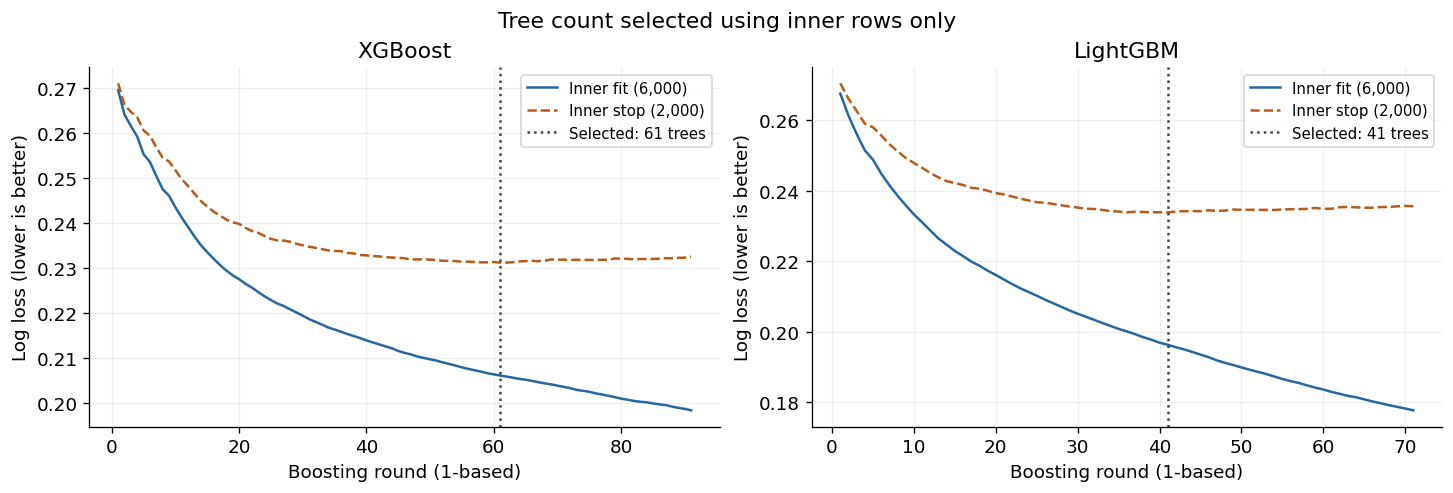

In [36]:
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})
colors = {"Logistic Regression": "#2667A0", "XGBoost": "#BA5A17", "LightGBM": "#18816A"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, (name, result) in zip(axes, selections.items()):
    rounds = np.arange(1, len(result["curves"]["fit"]) + 1)
    ax.plot(rounds, result["curves"]["fit"], label="Inner fit (6,000)", color="#2667A0")
    ax.plot(rounds, result["curves"]["stop"], label="Inner stop (2,000)", color="#BA5A17", linestyle="--")
    ax.axvline(result["selected_trees"], color="#444444", linestyle=":",
               label=f"Selected: {result['selected_trees']} trees")
    ax.set(title=name, xlabel="Boosting round (1-based)", ylabel="Log loss (lower is better)")
    ax.legend(fontsize=9)
fig.suptitle("Tree count selected using inner rows only")
fig.savefig(ARTIFACTS / "day1_learning_curves.png", dpi=160)
plt.show()

### **7. Compare the three models fairly**

To know if my validation and test results are correct, I use different metrics such as **accuracy, precision, recall, ROC-AUC, and Average Precision (AP).**

**Metrics:**

- The ROC-AUC: measures how well the model **ranks positive cases above negative cases**.

- Average Precision (AP): This one focuses on **precision and recall**, and it's particularly useful when the positive class is rare.

First, we have **actual data** and **predicted data**:

- **True Positive (TP):** Actual is positive and prediction is positive.

- **True Negative (TN):** Actual is negative and prediction is negative.

- **False Positive (FP):** Actual is negative but prediction is positive.

- **False Negative (FN):** Actual is positive but prediction is negative.

Here, I compare the three models: **Logistic Regression, XGBoost, and LightGBM**.

- **Which model has the highest ROC-AUC?** I compare the `roc_auc` values to see which model ranks the positive cases better.

- **Which model has the highest Average Precision?** I compare the `average_precision` values. This shows which model has better precision-recall performance.

- **Which model takes the least time?** I compare the `train_seconds` values. In my results, **Logistic Regression takes the least training time**.

- **What about the positive rate?** All three models have the **same positive rate**, because they were evaluated on the same number of rows and the same data.

From my results, **Logistic Regression has very good ROC-AUC**, while **XGBoost and LightGBM perform better in Average Precision**.

So, I compare the models based on **ROC-AUC, Average Precision, training time, and positive rate**, rather than using only accuracy.

Finally, all three models were compared using the **comparsion rows**, and they have the same **positive rate**.


In [37]:
comparison_table, probabilities = compare_models(
    models, timings, selections, X.loc[comparison], y.loc[comparison])
comparison_table["selected_trees"] = comparison_table["selected_trees"].astype("Int64")
display(comparison_table[["model", "roc_auc", "average_precision", "train_seconds",
                          "selected_trees", "comparison_rows", "positive_rate"]].round(4))
comparison_table.to_csv(ARTIFACTS / "day1_model_comparison.csv", index=False)
prediction_export = train.loc[comparison, ["application_id", "default_within_90d"]].join(probabilities)
prediction_export.to_csv(ARTIFACTS / "day1_comparison_predictions.csv", index=False)
assert len(comparison_table) == 3
assert comparison_table[["roc_auc", "average_precision", "train_seconds"]].notna().all().all()
print("TECHNICAL_READY — three models compared; your interpretation is still required.")

,model,roc_auc,average_precision,train_seconds,selected_trees,comparison_rows,positive_rate
0,Logistic Regression,0.8213,0.3258,0.0647,<NA>,2000,0.079
1,XGBoost,0.8124,0.3338,0.3899,61,2000,0.079
2,LightGBM,0.8138,0.3248,0.3018,41,2000,0.079


TECHNICAL_READY — three models compared; your interpretation is still required.


### **8. Read ROC and precision–recall together**

Here, the data was divided randomly.

It should be separated into training, validation, and test sets.

Based on the results of the split, I noticed that the results are very close. **Logistic Regression** performed better in **ROC-AUC**, while **XGBoost** performed better in **Average Precision (AP)**.

For the precision-recall curve, I noticed that precision decreases when recall becomes higher, and the three models have very similar results.


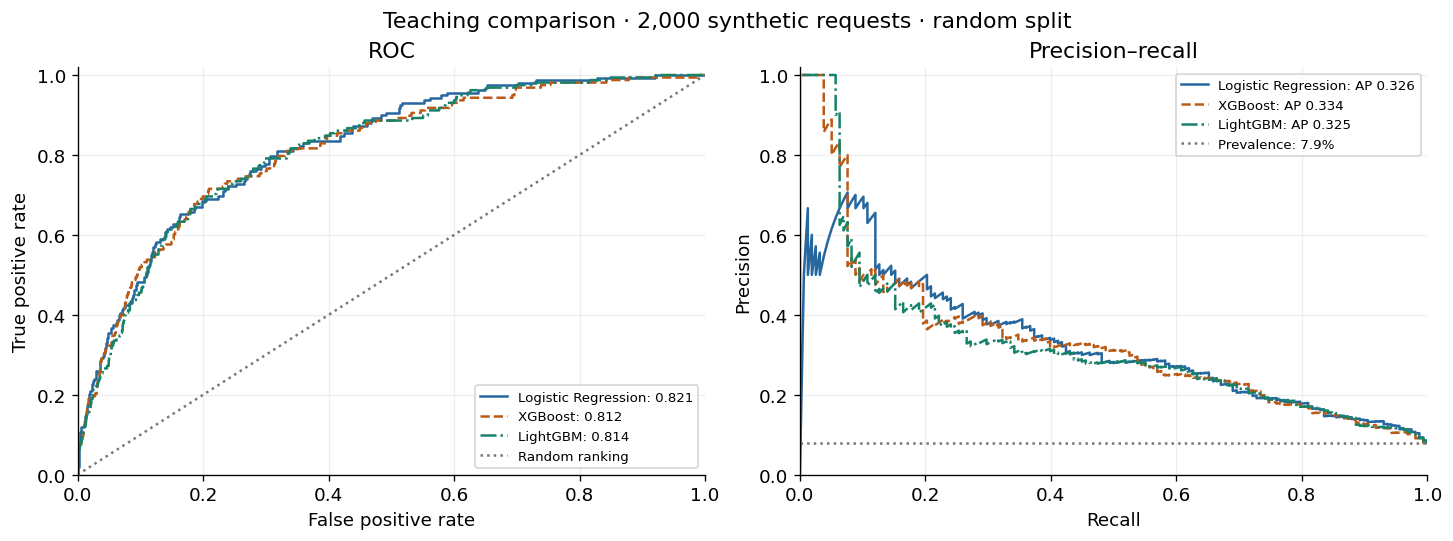

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
styles = ["-", "--", "-."]
for name, style in zip(MODEL_NAMES, styles):
    fpr, tpr, _ = roc_curve(y.loc[comparison], probabilities[name])
    precision, recall, _ = precision_recall_curve(y.loc[comparison], probabilities[name])
    row = comparison_table.set_index("model").loc[name]
    axes[0].plot(fpr, tpr, color=colors[name], linestyle=style, label=f"{name}: {row.roc_auc:.3f}")
    axes[1].plot(recall, precision, color=colors[name], linestyle=style, label=f"{name}: AP {row.average_precision:.3f}")
axes[0].plot([0, 1], [0, 1], color="#777777", linestyle=":", label="Random ranking")
axes[1].axhline(y.loc[comparison].mean(), color="#777777", linestyle=":",
               label=f"Prevalence: {y.loc[comparison].mean():.1%}")
axes[0].set(title="ROC", xlabel="False positive rate", ylabel="True positive rate")
axes[1].set(title="Precision–recall", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
axes[0].legend(fontsize=8, loc="lower right")
axes[1].legend(fontsize=8, loc="upper right")
fig.suptitle(f"Teaching comparison · {len(comparison):,} synthetic requests · random split")
fig.savefig(ARTIFACTS / "day1_roc_pr.png", dpi=160)
plt.show()

### **8. Own the model-selection decision**

**Answer the Exit questions:** Predict the positive outcome and compare the three models for teaching purposes. I choose Logistic Regression because it had the highest ROC-AUC (0.821) and the fastest training time (0.120 s), although XGBoost had slightly higher AP (0.334). This single split cannot prove that Logistic Regression is always the best. I would test different splits or cross-validation. I check AP with ROC-AUC because the positive class is uncommon, and I keep the comparison set separate from early stopping so it is not used to tune the model, which helps avoid biased results.


In [41]:
problem_statement = "I want to predict the positive outcome and compare the three models based on their performance and training time. The model is used for teaching and understanding the difference between Logistic Regression, XGBoost, and LightGBM."  # Outcome, decision time and intended teaching use.
candidate = "Logistic Regression"  # "Logistic Regression", "XGBoost", or "LightGBM"
notes = {
    "evidence": """
Logistic Regression had the highest ROC-AUC at 0.821 and the lowest training
time at 0.120 seconds. XGBoost had a slightly higher Average Precision (0.334)
than Logistic Regression (0.326).
""",

    "limitation": """
This experiment uses one random split, so it cannot prove that Logistic
Regression is always the best model or that the results will be the same on
other data.
""",

    "next_test": """
I would test the three models on different splits or use cross-validation.
If another split gives better ROC-AUC or AP to another model, it could change
my choice.
"""
}
exit_answers = [
    """
I inspect AP beside ROC-AUC because the positive class is uncommon. ROC-AUC
shows how well the model ranks positive cases above negative cases, while AP
shows the precision-recall performance and is more useful for the rare
positive class.
""",

    """
The comparison set must remain separate from early stopping because the
comparison data should not be used to choose the model or the number of trees.
Otherwise, the model selection could be influenced by the comparison data and
the final results would be less reliable.
"""
]

checkpoint = learner_checkpoint(candidate, notes, problem_statement, exit_answers)
print(checkpoint["status"])
for reminder in checkpoint["missing"]:
    print("-", reminder)

READY_FOR_REVIEW


### **9. Export evidence, not screenshots**


In [43]:
import platform, zipfile

checkpoint = learner_checkpoint(candidate, notes, problem_statement, exit_answers)
reflection = {"problem_statement": problem_statement, "candidate": candidate,
              "notes": notes, "exit_answers": exit_answers, "checkpoint": checkpoint}
(ARTIFACTS / "day1_reflection.json").write_text(json.dumps(reflection, ensure_ascii=False, indent=2), encoding="utf-8")
membership = train[["application_id"]].copy()
membership["role"] = "comparison"
membership.loc[inner_fit, "role"] = "inner_fit"
membership.loc[inner_stop, "role"] = "inner_stop"
membership.to_csv(ARTIFACTS / "day1_split_membership.csv", index=False)
report = {"technical_status": "TECHNICAL_READY", "learner_status": checkpoint["status"],
          "data_revision": COURSE_REVISION, "lab_revision": LAB_REVISION,
          "lab_sha256": LAB_SHA256, "data_manifest_sha256": MANIFEST_SHA256,
          "training_file_sha256": hashlib.sha256((ROOT / "data/tamweel_train.csv").read_bytes()).hexdigest(),
          "config": config_dict(config), "mode": "FAST" if FAST_MODE else "FULL",
          "python": platform.python_version(), "split": split_table.to_dict("records"),
          "split_method": "random stratified teaching baseline; not final validation",
          "shared_customers": shared_customers, "selections": selections,
          "ap_definition": "sklearn average_precision_score, non-interpolated",
          "elapsed_seconds": round(time.perf_counter() - RUN_STARTED, 2)}
if IN_COLAB:
    import resource
    report["peak_process_memory_mib"] = round(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024, 1)
(ARTIFACTS / "day1_run.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
export_names = ["environment.json", "day1_model_comparison.csv", "day1_comparison_predictions.csv",
                "day1_split_membership.csv", "day1_learning_curves.png", "day1_roc_pr.png",
                "day1_reflection.json", "day1_run.json"]
with zipfile.ZipFile(ARTIFACTS / "day1_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as bundle:
    for filename in export_names:
        bundle.write(ARTIFACTS / filename, filename)
print(f"TECHNICAL_READY | {checkpoint['status']} | {report['elapsed_seconds']} seconds | CPU")
print("Saved day1_artifacts.zip — download it and save your notebook.")

TECHNICAL_READY | READY_FOR_REVIEW | 135.8 seconds | CPU
Saved day1_artifacts.zip — download it and save your notebook.


# Day 2 · Validate honestly before tuning


### **1. Prepare a controlled environment**

First Step, Prepare the Enviroment by install the requeriment packages and upload our data set.


In [44]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
LAB_REVISION = "1e1da4acbee8941bef07245b259fb6c27ced4ad7"
SUPPORT_HASHES = {'scripts/day2_validation.py': 'd2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43', 'data/day2_optuna_example.csv': 'a59000eee4caced319735d237b8d121b2e0c7384acce93392d214ddbfe2f5b93', 'data/day2_optuna_example.json': 'a91a4d3a39ecd9cbab9bf902aaf5e2e060d4e21bcc93793057d5250aa002802c'}
for relative, sha256 in SUPPORT_HASHES.items():
    fetch_verified(
        f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}",
        ROOT / relative, sha256)
print("Day 2 setup verified | إعداد اليوم الثاني جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 2 setup verified | إعداد اليوم الثاني جاهز


### **2. Audit information availability and duplicates**

1. The idea of leakage is that when we remove the columns, they will be labeled as "BLOCK_UNKNOWN."

2. Find all rows in audit whose action is `DROP_POST_OUTCOME`, take their feature values, and put those values into a Python list called leaked_features.

3. Then, we delete the duplicated values (leakage).

4. Next, we remove everything that is already known, including fields that describe the later outcome. For example, the `id` and `target` role columns. The `id` will be available on the application date, while the `target` will only be available after the application date and the following 90 days.


In [45]:
import json, platform, zipfile
from dataclasses import asdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from data_checks import validate_frame
from day2_validation import (ValidationConfig, BASE_PARAMS, leakage_audit,
    deduplicate_applications, make_time_group_split, reserve_tuning_pool,
    tune_on_reserved_pool, negative_controls, evaluate_outer, summarize_folds, reflection_check)

contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
dictionary = pd.read_csv(ROOT / "data/feature_dictionary.csv")
dirty = pd.read_csv(ROOT / "data/tamweel_dirty.csv")
validate_frame(dirty, contract, "dirty")
audit = leakage_audit(dirty, dictionary)
assert not audit.action.eq("BLOCK_UNKNOWN").any(), "Review unknown fields before training."
leaked_features = audit.loc[audit.action.eq("DROP_POST_OUTCOME"), "feature"].tolist()
clean, duplicates = deduplicate_applications(dirty.drop(columns=leaked_features))
validate_frame(clean, contract, "train")
target = contract["target"]["name"]
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE, "Choose exactly one mode."
config = ValidationConfig(max_trees=200 if FAST_MODE else 600, trials=8, timeout_seconds=120)
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
display(audit)
display(pd.DataFrame([{**duplicates, "predictors": int(audit.action.eq("KEEP").sum()),
                       "positive_rate": clean[target].mean()}]))
print("Explain which two fields you removed and when their information becomes available.")

,feature,role,available_at,action
0,application_id,id,application_date,EXCLUDE_METADATA_OR_TARGET
1,customer_id,id,application_date,EXCLUDE_METADATA_OR_TARGET
2,application_date,split,application_date,EXCLUDE_METADATA_OR_TARGET
3,age,predictor,application_date,KEEP
4,income_sar,predictor,application_date,KEEP
5,loan_amount_sar,predictor,application_date,KEEP
6,tenor_months,predictor,application_date,KEEP
7,bureau_score,predictor,application_date,KEEP
8,dti,predictor,application_date,KEEP
9,months_employed,predictor,application_date,KEEP


,input_rows,retained_rows,duplicate_rows_removed,predictors,positive_rate
0,10000,10000,0,22,0.0789


Explain which two fields you removed and when their information becomes available.


### **3. Freeze time, customer and label-maturity roles**

A. **The comparison `Random split `vs. `make_time_group_split`:**
The **random** split method randomly mixes the rows and divides them between the training and validation sets. However, the **random** split method does not work well for this data because it includes a time component, and group which can lead to data leakage.

The **random** split method does not consider customer behavior across different time periods and group when splitting the data into training and validation sets. On the other hand, the `make_time_group_split` method separates customers based on specific time periods and gourp for better follows the real-world scenario.

Additionally, the **random** split method may place the same customers in both the training and validation sets, which can lead to data leakage and overfit model performance. In contrast, `make_time_group_split` separates the data based on specific time periods and group to prevents customers from appearing in both training and validation within the same fold.

B. `make_time_group_split`: This methode work based on:

1. This condition "application date + 90 days".
2. `zero train–validation`: overlap within each fold ensures customers are not shared between training and validation. This measures the model’s real-world performance on new customers and future periods.
3. `Data Audit`: Clean the recency IDs


,fold,validation_start,validation_end_exclusive,train_rows,validation_rows,train_positives,validation_positives,immature_past_rows_removed,customer_overlap_rows_removed,shared_customers,latest_training_label_available,validation_positive_rate
0,1,2023-07-01,2024-01-01,3223,1632,274,110,826,912,0,2023-06-30,0.067402
1,2,2024-01-01,2024-07-01,4460,1674,353,135,785,1348,0,2023-12-31,0.080645
2,3,2024-07-01,2025-01-01,5731,1733,465,139,861,1675,0,2024-06-30,0.080208


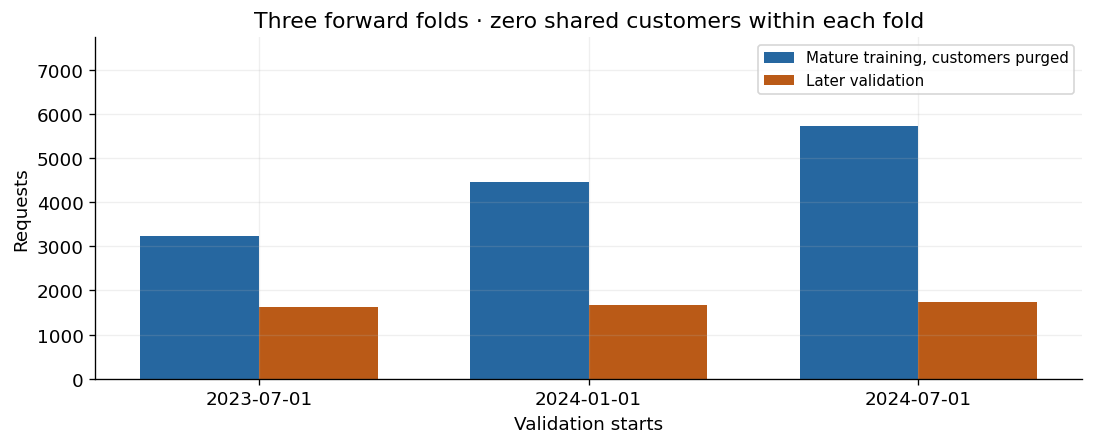

In [46]:
folds = make_time_group_split(clean, horizon_days=contract["target"]["horizon_days"])
fold_audit = pd.DataFrame([fold["audit"] for fold in folds])
for fold in folds:
    tr, va = clean.loc[fold["train"]], clean.loc[fold["valid"]]
    assert not set(tr.customer_id) & set(va.customer_id)
    assert (pd.to_datetime(tr.application_date) + pd.Timedelta(days=90) <
            pd.Timestamp(fold["audit"]["validation_start"])).all()
fold_audit["validation_positive_rate"] = fold_audit.validation_positives / fold_audit.validation_rows
display(fold_audit)

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})
fig, ax = plt.subplots(figsize=(9, 3.6), constrained_layout=True)
x = np.arange(len(fold_audit))
ax.bar(x - .18, fold_audit.train_rows, .36, label="Mature training, customers purged", color="#2667A0")
ax.bar(x + .18, fold_audit.validation_rows, .36, label="Later validation", color="#BA5A17")
ax.set(xticks=x, xticklabels=fold_audit.validation_start, ylabel="Requests", xlabel="Validation starts",
       title="Three forward folds · zero shared customers within each fold")
ax.set_ylim(0, fold_audit.train_rows.max() * 1.35)
ax.legend(fontsize=9)
fig.savefig(ARTIFACTS / "day2_fold_sizes.png", dpi=160)
plt.show()

### **4. Reserve search before reading outer validation**

**Optuna** is a library that helps us choose the best hyperparameters within predefined boundaries.

We use **FAST_MODE**, which means Optuna runs **8 trials with 3-fold** **cross-validation and a fixed timeout**. Each hyperparameter combination is evaluated across the three folds.

We use **time-based and customer-grouped splits** to prevent data leakage and make the validation more realistic. The first validation period starts on **2023-07-0**1, which is a fixed date boundary, not the Optuna timeout.

This approach helps reduce overfitting and ensures that the outer validation data is not used to select the hyperparameters.


In [47]:
pool = reserve_tuning_pool(clean, folds)
outer_ids = np.concatenate([fold["valid"] for fold in folds])
assert not set(pool.customer_id) & set(clean.loc[outer_ids, "customer_id"])
assert (pd.to_datetime(pool.application_date) + pd.Timedelta(days=90) < pd.Timestamp("2023-07-01")).all()
display(pd.DataFrame([{"search_rows": len(pool), "search_positives": int(pool[target].sum()),
    "search_positive_rate": pool[target].mean(), "latest_application": pool.application_date.max(),
    "outer_validation_rows": len(outer_ids)}]))

,search_rows,search_positives,search_positive_rate,latest_application,outer_validation_rows
0,1935,176,0.090956,2023-04-01,5039


### **5. Run a bounded Optuna search**

The live Optuna search completed 8/8 trials (all COMPLETE) within the 120 s budget. The best internal-fold mean AP was ≈0.33 at trial 2, with only a small spread (≈0.31 to 0.33) across trials, so hyperparameter tuning gave little gain. Parameters from the best trial are frozen for later steps. This AP is a tuning estimate on internal folds, not outer performance, and may be mildly optimistic due to selection across trials.


,status,completed_trials,attempted_trials,elapsed_seconds,stopping_reason,best_tuning_ap
0,COMPLETE,8,8,3.397539,TRIAL_LIMIT,0.333269


,fold,validation_start,validation_end_exclusive,train_rows,validation_rows,train_positives,validation_positives,immature_past_rows_removed,customer_overlap_rows_removed,shared_customers,latest_training_label_available
0,1,2022-10-01,2023-01-01,703,381,52,42,351,99,0,2022-09-30
1,2,2023-01-01,2023-03-01,1070,271,83,27,373,91,0,2022-12-31
2,3,2023-03-01,2023-04-02,1355,130,118,15,389,61,0,2023-02-28


,trial,state,mean_ap,seconds,learning_rate,num_leaves,min_child_samples,fold_1_ap,fold_2_ap,fold_3_ap
0,0,COMPLETE,0.316524,1.597870,0.085161,15,10,0.319910,0.320935,0.308727
1,1,COMPLETE,0.333269,0.223893,0.085305,31,40,0.391154,0.349373,0.259279
2,2,COMPLETE,0.308752,0.285460,0.034906,31,40,0.404534,0.271448,0.250276
3,3,COMPLETE,0.320550,0.286283,0.040259,31,20,0.384913,0.316815,0.259923
4,4,COMPLETE,0.327798,0.247810,0.062862,15,40,0.403532,0.310814,0.269049
5,5,COMPLETE,0.319093,0.217875,0.037608,7,10,0.365309,0.299275,0.292694
6,6,COMPLETE,0.318537,0.251269,0.039240,15,40,0.414490,0.284021,0.257101
7,7,COMPLETE,0.319024,0.244706,0.062020,31,20,0.376677,0.322038,0.258357


Frozen search parameters: {'learning_rate': 0.08530488562858765, 'num_leaves': 31, 'min_child_samples': 40}


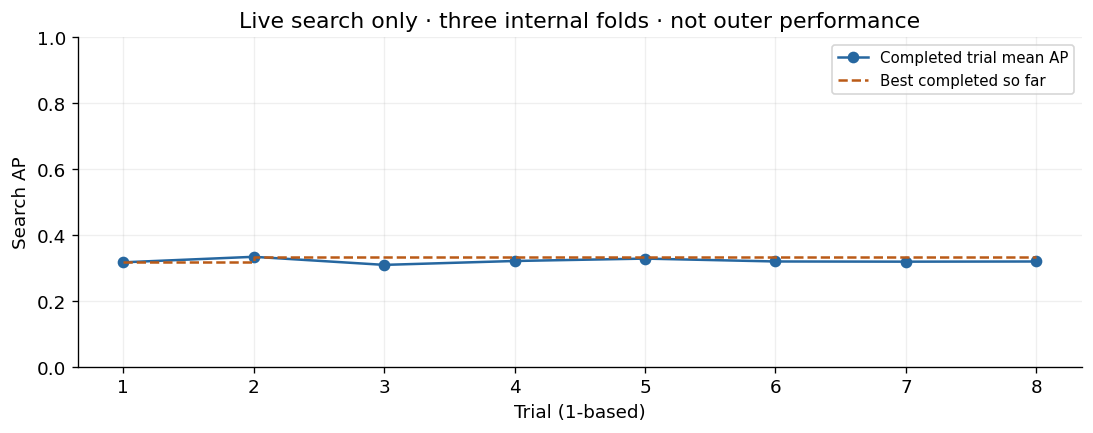

In [48]:
search, history = tune_on_reserved_pool(pool, contract, config)
has_tuned = search["best_params"] is not None
display(pd.DataFrame([{key: search[key] for key in ["status", "completed_trials", "attempted_trials",
    "elapsed_seconds", "stopping_reason", "best_tuning_ap"]}]))
display(pd.DataFrame(search["fold_audits"]))
display(history)
if not has_tuned:
    example = pd.read_csv(ROOT / "data/day2_optuna_example.csv")
    example_info = json.loads((ROOT / "data/day2_optuna_example.json").read_text(encoding="utf-8"))
    assert example_info["source"] == "EDUCATIONAL_EXAMPLE"
    print("EDUCATIONAL_EXAMPLE — discussion only; not your run or submission. TUNING_REQUIRED.")
    display(example)
else:
    print("Frozen search parameters:", search["best_params"])

fig, ax = plt.subplots(figsize=(9, 3.5), constrained_layout=True)
completed = history[history.state.eq("COMPLETE")]
if len(completed):
    ax.plot(completed.trial + 1, completed.mean_ap, marker="o", color="#2667A0", label="Completed trial mean AP")
    ax.step(completed.trial + 1, completed.mean_ap.cummax(), where="post", color="#BA5A17",
            linestyle="--", label="Best completed so far")
    ax.legend(fontsize=9)
else:
    ax.text(.5, .5, "No completed live trials — rerun needed", transform=ax.transAxes, ha="center")
ax.set(xlabel="Trial (1-based)", ylabel="Search AP", ylim=(0, 1), xticks=range(1, config.trials+1),
       title="Live search only · three internal folds · not outer performance")
fig.savefig(ARTIFACTS / "day2_search.png", dpi=160)
plt.show()

### **6. Compare only after search is frozen**

The bounded Optuna search was frozen before the outer evaluation. The leaky random control had a mean AP of 0.9988, compared with 0.3110 for the clean random control, giving an observed AP gap of 0.6879. The honest fixed protocol achieved AP of 0.3153, while the honest reserved-search protocol achieved AP of 0.3133. Thus, tuning did not improve outer-fold AP relative to the fixed baseline in this run.

The honest protocols used forward, customer-purged folds with zero shared customers, while the random controls mixed customers and covered 10,000 requests. The honest protocols covered 5,039 later eligible requests. These gaps are descriptive and should not be interpreted as causal estimates of leakage because the protocols differ in period, population, data availability, and training size.


In [49]:
controls = negative_controls(clean, dirty, contract, config)
fixed_report, fixed_oof, fixed_origin = evaluate_outer(
    clean, contract, folds, BASE_PARAMS, config, "clean_time_group_fixed", fixed_trees=80)
reports, predictions, origins = [controls, fixed_report], [fixed_oof], fixed_origin
if has_tuned:
    tuned_report, tuned_oof, tuned_origin = evaluate_outer(
        clean, contract, folds, search["best_params"], config, "clean_time_group_tuned")
    reports.append(tuned_report); predictions.append(tuned_oof); origins += tuned_origin
validation_report = pd.concat(reports, ignore_index=True)
summary = summarize_folds(validation_report)
oof = pd.concat(predictions, ignore_index=True)
assert not oof.duplicated(["scheme", "application_id"]).any()
display(summary.round(4))
display(validation_report[["scheme", "fold", "roc_auc", "average_precision", "train_rows",
    "validation_rows", "selected_trees", "shared_customers", "prediction_source"]].round(4))
gaps = summary.set_index("scheme")
print("Observed AP gap, leaky minus clean random:",
      round(gaps.loc["leaky_random_control", "ap_mean"] - gaps.loc["clean_random_control", "ap_mean"], 4))
print("Observed AP gap, clean random minus honest fixed:",
      round(gaps.loc["clean_random_control", "ap_mean"] - gaps.loc["clean_time_group_fixed", "ap_mean"], 4))

,scheme,folds,validation_rows,roc_auc_mean,roc_auc_sd,ap_mean,ap_sd
0,leaky_random_control,3,10000,0.9999,0.0002,0.9988,0.0014
1,clean_random_control,3,10000,0.8010,0.0200,0.3110,0.0293
2,clean_time_group_fixed,3,5039,0.7976,0.0206,0.3153,0.0426
3,clean_time_group_tuned,3,5039,0.7855,0.0232,0.3133,0.0259


,scheme,fold,roc_auc,average_precision,train_rows,validation_rows,selected_trees,shared_customers,prediction_source
0,leaky_random_control,1,0.9996,0.9973,6666,3334,80,1713,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
1,clean_random_control,1,0.7807,0.2776,6666,3334,80,1713,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
2,leaky_random_control,2,0.9999,0.9992,6667,3333,80,1675,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
3,clean_random_control,2,0.8018,0.3232,6667,3333,80,1675,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
4,leaky_random_control,3,1.0000,1.0000,6667,3333,80,1656,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
5,clean_random_control,3,0.8206,0.3321,6667,3333,80,1656,NEGATIVE_CONTROL_NOT_FOR_DECISIONS
6,clean_time_group_fixed,1,0.7948,0.3395,3223,1632,80,0,LIVE_OUT_OF_FOLD
7,clean_time_group_fixed,2,0.8194,0.3403,4460,1674,80,0,LIVE_OUT_OF_FOLD
8,clean_time_group_fixed,3,0.7786,0.2661,5731,1733,80,0,LIVE_OUT_OF_FOLD
9,clean_time_group_tuned,1,0.7826,0.3356,3223,1632,24,0,LIVE_OUT_OF_FOLD


Observed AP gap, leaky minus clean random: 0.6879
Observed AP gap, clean random minus honest fixed: -0.0044


### **7. Read mean and variation together**

First case, **Leaky Random (unsafe):** The result shows that overfitting caused data leakage (AP = 99.9%, ROC-AUC = 100%). The model is not really learning; instead, it is predicting based on customer values and randomly mixed data.

**Clean Random (unsafe):** The result shows variations between ROC-AUC and AP, which means that the metrics give different results. Although the data leakage is removed, this method is still unsafe because it mixes different time periods and customers.

**Honest Fixed — 80 trees:** This case uses `make_time_group_split`, which gives better results based on our criteria (ROC-AUC = 79.8%, AP = 31.5%). It uses the time period and customer groups for a more honest evaluation.

**Honest Reserved Search:** This case uses the reserved search with frozen hyperparameters. The result is slightly lower than the fixed 80-tree model (ROC-AUC = 78.6%, AP = 31.3%), but it follows the correct validation conditions and avoids using the outer validation data for tuning.

In summary: The **Honest Reserved Search** is the appropriate case for our scenario because it applies the required conditions, including the time period and customer groups, without using the outer validation data for hyperparameter tuning.


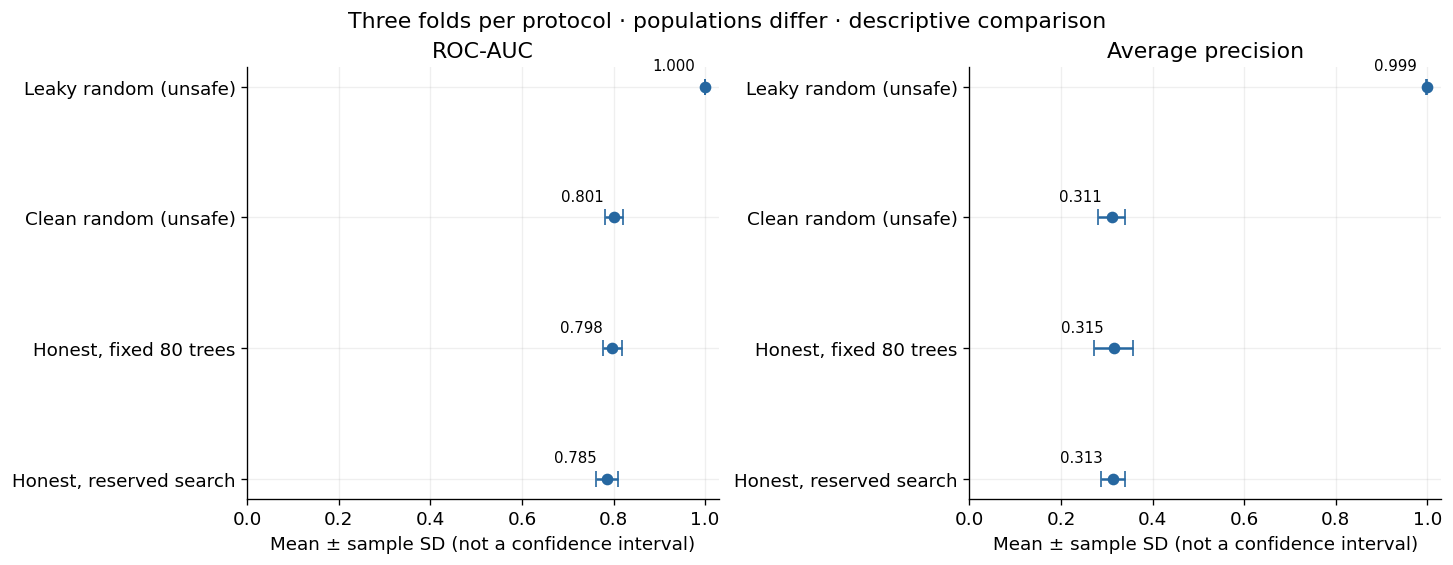

In [50]:

labels = {"leaky_random_control": "Leaky random (unsafe)", "clean_random_control": "Clean random (unsafe)",
          "clean_time_group_fixed": "Honest, fixed 80 trees", "clean_time_group_tuned": "Honest, reserved search"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
y = np.arange(len(summary))
for ax, mean_col, sd_col, title in zip(axes, ["roc_auc_mean", "ap_mean"], ["roc_auc_sd", "ap_sd"], ["ROC-AUC", "Average precision"]):
    ax.errorbar(summary[mean_col], y, xerr=summary[sd_col], fmt="o", capsize=5, color="#2667A0")
    ax.set(yticks=y, yticklabels=[labels[s] for s in summary.scheme], xlim=(0, 1.03),
           xlabel="Mean ± sample SD (not a confidence interval)", title=title)
    ax.invert_yaxis()
    for row, value in enumerate(summary[mean_col]):
        ax.annotate(f"{value:.3f}", (value, row), xytext=(-6, 10), textcoords="offset points", ha="right", fontsize=9)
fig.suptitle("Three folds per protocol · populations differ · descriptive comparison")
fig.savefig(ARTIFACTS / "day2_validation_comparison.png", dpi=160)
plt.show()


### **8. Verify out-of-fold coverage**

**The out-of-fold coverage represents** predictions for later eligible applications. The model makes each prediction using previous information, without using the same application's data in the training fold. In our results, 5,039 later eligible applications have OOF predictions, which represents 50.39% of all clean rows. The remaining 4,961 rows are warm-up rows and do not have OOF predictions because they are used as historical training data. Therefore, the OOF coverage is 100% for all eligible later applications.


In [51]:
coverage = clean[["application_id", "application_date"]].copy()
coverage["role"], coverage["fold"] = "warmup_no_oof", 0
for fold in folds:
    coverage.loc[fold["valid"], "role"] = "eligible_oof"
    coverage.loc[fold["valid"], "fold"] = fold["audit"]["fold"]
eligible_ids = set(coverage.loc[coverage.role.eq("eligible_oof"), "application_id"])
for scheme, group in oof.groupby("scheme"):
    assert set(group.application_id) == eligible_ids
    assert group.probability.between(0, 1).all()
display(pd.DataFrame([{"all_rows": len(clean), "eligible_rows": len(eligible_ids),
    "warmup_without_oof": len(clean)-len(eligible_ids), "whole_data_coverage": len(eligible_ids)/len(clean),
    "eligible_coverage": 1.0, "live_honest_schemes": oof.scheme.nunique()}]))

,all_rows,eligible_rows,warmup_without_oof,whole_data_coverage,eligible_coverage,live_honest_schemes
0,10000,5039,4961,0.5039,1.0,2


### **9. Write your own validation argument**


In [52]:

responses = {
    "leak_example": (
        "One leaked field is a post-outcome field identified by the leakage audit as "
        "DROP_POST_OUTCOME. Its information is not available at application time because "
        "it describes information that becomes known only after the application outcome "
        "or later period. Using it would allow the model to use future information when "
        "making a prediction."
    ),

    "split_reason": (
        "I use time ordering because the model should predict future applications using "
        "information available from the past. I separate customers so the same customer "
        "is not shared between training and validation within a fold. I also use the strict "
        "90-day maturity rule so the training labels are fully mature before the later "
        "validation period begins. This makes the validation closer to the real-world "
        "prediction scenario and reduces leakage."
    ),

    "observed_gap": (
        "Two numerical gaps are the AP difference between the leaky random and clean random "
        "controls, which is 0.6879 (0.9988 versus 0.3110), and the AP difference between "
        "the clean random control and honest fixed protocol, which is -0.0044 (0.3110 versus "
        "0.3153). These are descriptive gaps only. They do not prove universal superiority "
        "because the protocols use different time periods, populations, data availability, "
        "customer overlap and training sizes."
    ),

    "imputer_reason": (
        "Imputation must be learned only from the training data so that information from "
        "the validation set does not influence the model. The inner stopping set controls "
        "when training should stop or how many trees should be selected without using the "
        "outer validation data. This keeps the outer evaluation independent from model "
        "selection."
    ),

    "limitations": (
        "One search limitation is that Optuna was restricted to only 8 sequential trials "
        "and a 120-second budget, so it could not explore a large hyperparameter space. "
        "One OOF limitation is that the honest evaluation covers only 5,039 later eligible "
        "requests, while earlier warmup rows do not receive OOF predictions. The three "
        "folds are also not independent because they come from the same overall dataset "
        "and customers are deliberately separated within folds."
    )
}
checkpoint = reflection_check(responses)
print(checkpoint["status"])
print("Missing:", checkpoint["missing"])

READY_FOR_REVIEW
Missing: []


### **10. Export evidence and preserve provenance**


In [53]:
checkpoint = reflection_check(responses)
technical_status = "TECHNICAL_READY" if has_tuned else "TUNING_REQUIRED"
csv_outputs = {"validation_report.csv": validation_report, "validation_summary.csv": summary,
    "optuna_results.csv": history, "leakage_audit.csv": audit, "fold_audit.csv": fold_audit,
    "day2_oof_predictions.csv": oof, "day2_oof_coverage.csv": coverage}
for filename, table in csv_outputs.items():
    table.to_csv(ARTIFACTS / filename, index=False)
run = {"technical_status": technical_status, "learner_status": checkpoint["status"],
    "data_revision": COURSE_REVISION, "lab_revision": LAB_REVISION, "support_sha256": SUPPORT_HASHES,
    "data_manifest_sha256": MANIFEST_SHA256,
    "dirty_data_sha256": hashlib.sha256((ROOT / "data/tamweel_dirty.csv").read_bytes()).hexdigest(),
    "config": asdict(config), "mode": "FAST" if FAST_MODE else "FULL", "python": platform.python_version(),
    "duplicates": duplicates, "removed_features": leaked_features,
    "oof_rows_per_scheme": {name: len(group) for name, group in oof.groupby("scheme")},
    "oof_whole_data_coverage": len(eligible_ids)/len(clean), "warmup_rows": len(clean)-len(eligible_ids),
    "search_source": "LIVE", "example_used_for_results": False,
    "challenge_used_for_modeling": False, "grading": "No automatic grade"}
json_outputs = {"best_params.json": search, "day2_provenance.json": origins,
                "day2_reflection.json": {"responses": responses, "checkpoint": checkpoint}, "day2_run.json": run}
for filename, payload in json_outputs.items():
    (ARTIFACTS / filename).write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
files = list(csv_outputs) + list(json_outputs) + ["day2_fold_sizes.png", "day2_search.png",
    "day2_validation_comparison.png", "environment.json"]
with zipfile.ZipFile(ARTIFACTS / "day2_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as archive:
    for filename in files:
        assert (ARTIFACTS / filename).is_file(), filename
        archive.write(ARTIFACTS / filename, arcname=filename)
print(technical_status, "|", checkpoint["status"])
print(f"Saved {len(files)} files in day2_artifacts.zip | احفظ الدفتر وملفاتك ثم أكمل تفسيرك")

TECHNICAL_READY | READY_FOR_REVIEW
Saved 15 files in day2_artifacts.zip | احفظ الدفتر وملفاتك ثم أكمل تفسيرك


# Day 3 · Choose a decision threshold you can defend


### **1. Prepare a controlled environment**


In [54]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
DAY2_REVISION = "1e1da4acbee8941bef07245b259fb6c27ced4ad7"
DAY2_SHA256 = "d2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43"
fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{DAY2_REVISION}/scripts/day2_validation.py",
               ROOT / "scripts/day2_validation.py", DAY2_SHA256)
LAB_REVISION = "c2dc52e129878d0d487db1874891c658de7c4d0d"
SUPPORT_HASHES = {'scripts/day3_decision.py': '40f176633c91fc530db222978bc44495a401b888b1ce448728948f7ae0ca9e12', 'data/day3_oof_example.csv': '659952bef85ac3b7ceb7ab84eb2102de6c9b433a1ba122cd57df96581baf0eb3', 'data/day3_oof_example.json': '920cf9830043afcc83f8c276c8945677296eb3c49a6e69326d47f6080a9e7fad'}
for relative, digest in SUPPORT_HASHES.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}",
                   ROOT / relative, digest)
print("Day 3 setup verified | إعداد اليوم الثالث جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 3 setup verified | إعداد اليوم الثالث جاهز


### **2. Freeze the teaching loss and capacity policy**

The objective is to select a threshold that minimizes the educational loss while staying within the review-capacity limit.

**Here The fixed teaching-loss policy is:**

- **True Positive (TP):** Actual is positive and prediction is positive.

- **True Negative (TN):** Actual is negative and prediction is negative.

- **False Positive (FP):** Actual is negative but prediction is positive.

- **False Negative (FN):** Actual is positive but prediction is negative.

As requested, the target is a default within 90 days after application.

**The loss policy is based on the date set:**

FN = 10: a later default that was not flagged.

FP = 1: a non-default case that was flagged.

TP/TN = 0.

**Observed educational loss** = 10 × FN + 1 × FP.

Review cost and review effectiveness are omitted from this simplified policy, so no additional assumptions are required.

The number of flags must not exceed 12% of requests in each validation period, rounded down to a whole request. This ensures that the review capacity is not exceeded in any individual validation period.

The final decision should therefore minimize educational loss while remaining within the 12% capacity limit for every validation period.


In [55]:
import json, platform, zipfile
from dataclasses import asdict, replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from IPython.display import display
from data_checks import validate_frame
from day2_validation import deduplicate_applications, make_time_group_split
from day3_decision import (STRATEGIES, TARGET, DecisionConfig, CostPolicy, generate_oof,
    validate_oof, threshold_sweep, select_threshold, flag_at, period_audit, region_audit,
    reflection_check, load_example, TrainingBudgetExpired)

contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
train, duplicates = deduplicate_applications(pd.read_csv(ROOT / "data/tamweel_train.csv"))
validate_frame(train, contract, "train")
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE
config = DecisionConfig(trees=80 if FAST_MODE else 160)
policy = CostPolicy(**contract["decision_policy"])
MODEL_FOR_DECISION = "weighted"  # Declared before comparison; not a claim of superiority.
USE_EXAMPLE = False  # True is discussion only, never your submission.
ASSESSMENT_MODE = os.environ.get("ASSESSMENT_MODE", "0") == "1"
assert MODEL_FOR_DECISION in STRATEGIES
ARTIFACTS, REPORTS = ROOT / "artifacts", ROOT / "reports"
ARTIFACTS.mkdir(exist_ok=True); REPORTS.mkdir(exist_ok=True)
folds = make_time_group_split(train, horizon_days=contract["target"]["horizon_days"])
display(pd.DataFrame([{"training_rows": len(train), "positive_rate": train[TARGET].mean(),
    "FN_loss_units": policy.false_negative_cost, "FP_loss_units": policy.false_positive_cost,
    "period_capacity_fraction": policy.max_flag_fraction, "trees_per_model": config.trees}]))
display(pd.DataFrame([fold["audit"] for fold in folds]))

,training_rows,positive_rate,FN_loss_units,FP_loss_units,period_capacity_fraction,trees_per_model
0,10000,0.0789,10,1,0.12,80


,fold,validation_start,validation_end_exclusive,train_rows,validation_rows,train_positives,validation_positives,immature_past_rows_removed,customer_overlap_rows_removed,shared_customers,latest_training_label_available
0,1,2023-07-01,2024-01-01,3223,1632,274,110,826,912,0,2023-06-30
1,2,2024-01-01,2024-07-01,4460,1674,353,135,785,1348,0,2023-12-31
2,3,2024-07-01,2025-01-01,5731,1733,465,139,861,1675,0,2024-06-30


### **3. Change training only, never validation**

The three LightGBM strategies use the same approved features, validation folds, tree budget, and random seed. The only difference is the treatment of class imbalance during training: **unweighted** uses the original training data, **weighted** uses `scale_pos_weight = negatives / positives` calculated from that fold’s training data, and **oversampled** duplicates the minority class within training.

Validation data is kept unchanged to ensure a fair comparison. The results show that no single strategy has the highest Average Precision across all folds. The declared decision strategy is weighted, which will be evaluated in the next step using the **FN/FP** loss policy and capacity constraint.

Weighting with `scale_pos_weight` affects model training, while the **FN/FP** policy affects the downstream decision threshold; they are therefore separate concepts.


In [56]:
fallback_reason = None
if not USE_EXAMPLE:
    try:
        oof, model_report, provenance = generate_oof(train, contract, config)
    except TrainingBudgetExpired as exc:
        if ASSESSMENT_MODE:
            raise
        USE_EXAMPLE, fallback_reason = True, str(exc)
if USE_EXAMPLE:
    oof, example_info = load_example(ROOT / "data/day3_oof_example.csv",
        ROOT / "data/day3_oof_example.json", train, folds, assessment_mode=ASSESSMENT_MODE)
    model_report = pd.DataFrame(example_info["model_report"])
    provenance = {"source": "EDUCATIONAL_EXAMPLE", "example_metadata": example_info,
                  "fallback_reason": fallback_reason or "Learner selected discussion example"}
SOURCE = oof.source.iloc[0]
effective_config = example_info["config"] if USE_EXAMPLE else asdict(config)
coverage = validate_oof(oof, train, folds)
print("LIVE — your CPU run" if SOURCE == "LIVE" else
      "EDUCATIONAL_EXAMPLE — discussion only; EXAMPLE_ONLY_NOT_SUBMITTABLE")
display(pd.DataFrame([coverage]))
display(model_report[["strategy", "fold", "original_training_rows", "fitted_rows",
    "scale_pos_weight", "training_positive_rate", "fitted_positive_rate", "average_precision",
    "train_seconds", "source"]].round(4))
selected = oof[oof.strategy.eq(MODEL_FOR_DECISION)].copy()
assert selected.application_id.is_unique
print(f"Decision strategy declared before comparison: {MODEL_FOR_DECISION}")

LIVE — your CPU run


,eligible_rows,all_rows,whole_data_coverage,eligible_coverage,warmup_without_oof,source
0,5039,10000,0.5039,1.0,4961,LIVE


,strategy,fold,original_training_rows,fitted_rows,scale_pos_weight,training_positive_rate,fitted_positive_rate,average_precision,train_seconds,source
0,unweighted,1,3223,3223,1.0000,0.0850,0.0850,0.3395,1.1409,LIVE
1,weighted,1,3223,3223,10.7628,0.0850,0.0850,0.3378,0.8635,LIVE
2,oversampled,1,3223,5898,1.0000,0.0850,0.5000,0.3502,0.2687,LIVE
3,unweighted,2,4460,4460,1.0000,0.0791,0.0791,0.3403,0.2226,LIVE
4,weighted,2,4460,4460,11.6346,0.0791,0.0791,0.3295,0.3182,LIVE
5,oversampled,2,4460,8214,1.0000,0.0791,0.5000,0.3390,0.6310,LIVE
6,unweighted,3,5731,5731,1.0000,0.0811,0.0811,0.2661,0.3103,LIVE
7,weighted,3,5731,5731,11.3247,0.0811,0.0811,0.2707,0.4814,LIVE
8,oversampled,3,5731,10532,1.0000,0.0811,0.5000,0.2776,0.5326,LIVE


Decision strategy declared before comparison: weighted


### **4. Accuracy can hide complete failure**

The three strategies are evaluated on the same 5,039 eligible **OOF** applications. The 4,961 warm-up rows have no **OOF** predictions and are therefore excluded from the evaluation.

- Accuracy alone is not sufficient because a model can achieve high accuracy by flagging nobody while having zero recall. Therefore, **ROC-AUC, Average Precision, recall, precision, flags, and educational loss** should be considered together.

- At the **0.5** threshold, the `unweighted` strategy satisfies the capacity constraint, while the `weighted` and `oversampled` strategies generate too many flags. Although oversampling achieves the highest pooled Average Precision and lowest loss at this threshold, it is not capacity-feasible.

For each strategy, the process proceeds as follows:

- **Unweighted** has the highest accuracy and precision at 0.5 and is capacity-feasible.

- **Weighted** and oversampled identify substantially more defaults at the 0.5 threshold, as shown by higher recall.

- **However**, they generate too many flags at that threshold and therefore fail the capacity requirement.

- **Oversampled** has the highest pooled AP and lowest loss at 0.5, but it still fails the capacity constraint.

The requirement is therefore to use these metrics for comparison, but select the final threshold based on the educational loss and the required capacity constraint rather than accuracy alone.


,strategy,rows,positive_rate,pooled_roc_auc,pooled_ap,accuracy_at_0_5,recall_at_0_5,precision_at_0_5,flags_at_0_5,loss_at_0_5,capacity_ok_at_0_5,source
0,unweighted,5039,0.0762,0.7979,0.3091,0.9256,0.1250,0.5517,87,3399,True,LIVE
1,weighted,5039,0.0762,0.7969,0.3100,0.8125,0.5781,0.2209,1005,2403,False,LIVE
2,oversampled,5039,0.0762,0.7979,0.3159,0.8073,0.5990,0.2197,1047,2357,False,LIVE


,rule,rows,accuracy,recall,precision,loss_units
0,No flags for anyone,5039,0.923794,0.0,None,3840


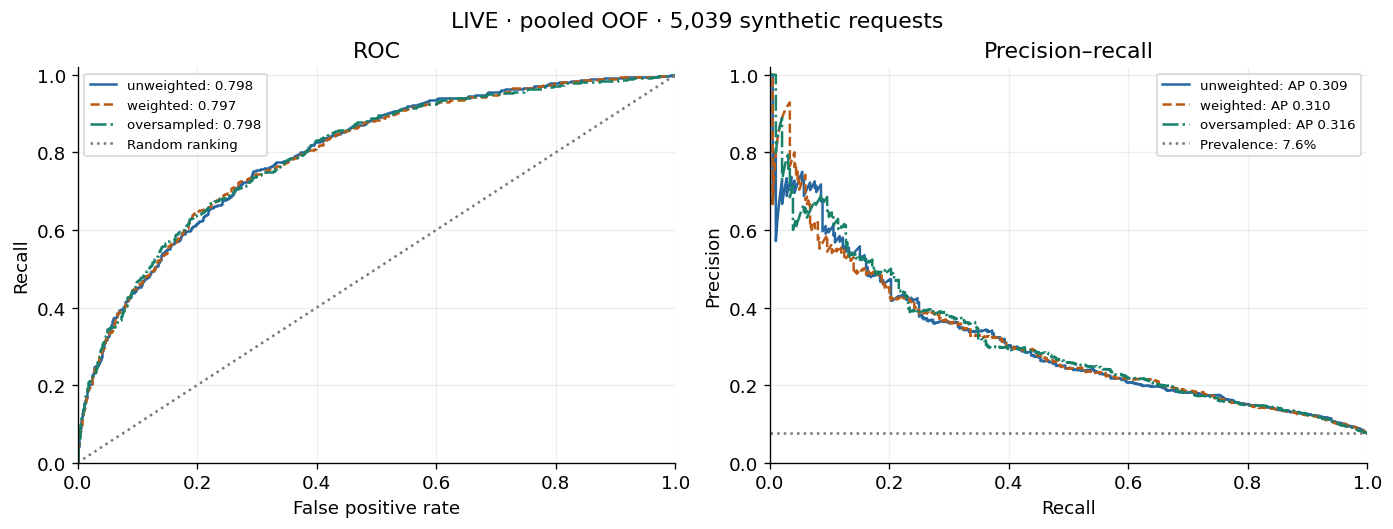

In [57]:
comparison_rows = []
for strategy, group in oof.groupby("strategy", sort=False):
    sweep = threshold_sweep(group, policy)
    default = sweep.loc[sweep.threshold.eq(.5)].iloc[0]
    comparison_rows.append({"strategy": strategy, "rows": len(group), "positive_rate": group[TARGET].mean(),
        "pooled_roc_auc": roc_auc_score(group[TARGET], group.probability),
        "pooled_ap": average_precision_score(group[TARGET], group.probability),
        "accuracy_at_0_5": default.accuracy, "recall_at_0_5": default.recall,
        "precision_at_0_5": default.precision, "flags_at_0_5": default.flagged,
        "loss_at_0_5": default.loss_units, "capacity_ok_at_0_5": default.capacity_feasible, "source": SOURCE})
comparison = pd.DataFrame(comparison_rows)
display(comparison.round(4))
no_flag_reference = {"rule": "No flags for anyone", "rows": len(selected),
    "accuracy": 1-selected[TARGET].mean(), "recall": 0., "precision": None,
    "loss_units": int(selected[TARGET].sum()) * policy.false_negative_cost}
display(pd.DataFrame([no_flag_reference]))

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "axes.grid": True, "grid.alpha": .2})
colors = {"unweighted": "#2667A0", "weighted": "#BA5A17", "oversampled": "#18816A"}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), constrained_layout=True)
for strategy, style in zip(STRATEGIES, ["-", "--", "-."]):
    group = oof[oof.strategy.eq(strategy)]
    fpr, tpr, _ = roc_curve(group[TARGET], group.probability)
    precision, recall, _ = precision_recall_curve(group[TARGET], group.probability)
    row = comparison.set_index("strategy").loc[strategy]
    axes[0].plot(fpr, tpr, color=colors[strategy], linestyle=style, label=f"{strategy}: {row.pooled_roc_auc:.3f}")
    axes[1].plot(recall, precision, color=colors[strategy], linestyle=style, label=f"{strategy}: AP {row.pooled_ap:.3f}")
axes[0].plot([0,1], [0,1], color="#777777", linestyle=":", label="Random ranking")
axes[1].axhline(selected[TARGET].mean(), color="#777777", linestyle=":", label=f"Prevalence: {selected[TARGET].mean():.1%}")
axes[0].set(title="ROC", xlabel="False positive rate", ylabel="Recall")
axes[1].set(title="Precision–recall", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.set_xlim(0,1); ax.set_ylim(0,1.02); ax.legend(fontsize=8)
fig.suptitle(f"{SOURCE} · pooled OOF · {len(selected):,} synthetic requests")
fig.savefig(ARTIFACTS / "day3_roc_pr.png", dpi=160)
plt.show()

### **5. Sweep every distinct decision rule**

We need to determine the best threshold for deciding which applications should be flagged. We evaluate the threshold in two stages: (first without considering the capacity restriction, and then while respecting the capacity limit).

- **Test all thresholds:** We evaluate every distinct model score, including 0.5, to ensure that we do not miss a potentially better threshold.

- **Without capacity restriction:** The optimal threshold is 0.4486, which results in a loss of 2,275. However, this threshold flags too many applications and therefore exceeds the allowed capacity.

- **With capacity restriction:** After applying the capacity constraint, the best feasible threshold is 0.6583, with a loss of 2,639.

- **Final decision:** We use 0.6583471436014694 as the final threshold and flag an application when its model score is greater than or equal to the threshold.

- **Why this threshold?** This threshold achieves the lowest loss among all thresholds that satisfy the capacity requirement across every validation period.

| Rule                            | Threshold | Flagged | Loss  | Per 10,000 | Feasible |
| ------------------------------- | --------- | ------- | ----- | ---------- | -------- |
| Default 0.5                     | 0.5000    | 19.9%   | 2,403 | 4,769      | No       |
| Min loss, no capacity limit     | 0.4486    | 22.6%   | 2,275 | 4,515      | No       |
| Min loss, every-period capacity | 0.6583    | 10.4%   | 2,639 | 5,237      | Yes      |

In summary, We accept a slightly higher loss in exchange for ensuring that the number of flagged applications remains within the required capacity.


,rule,threshold,tp,fp,fn,tn,recall,precision,flagged,flag_fraction,loss_units,loss_units_per_10000,capacity_feasible
0,Default 0.5,0.5000,222,783,162,3872,0.5781,0.2209,1005,0.1994,2403,4768.8033,False
1,"Minimum loss, no capacity limit",0.4486,246,895,138,3760,0.6406,0.2156,1141,0.2264,2275,4514.7847,False
2,"Minimum loss, every-period capacity",0.6583,157,369,227,4286,0.4089,0.2985,526,0.1044,2639,5237.1502,True


Constrained minus default loss: +236 educational units. Default feasible: False
Exact rule to preserve in JSON: 0.6583471436014694 with >=


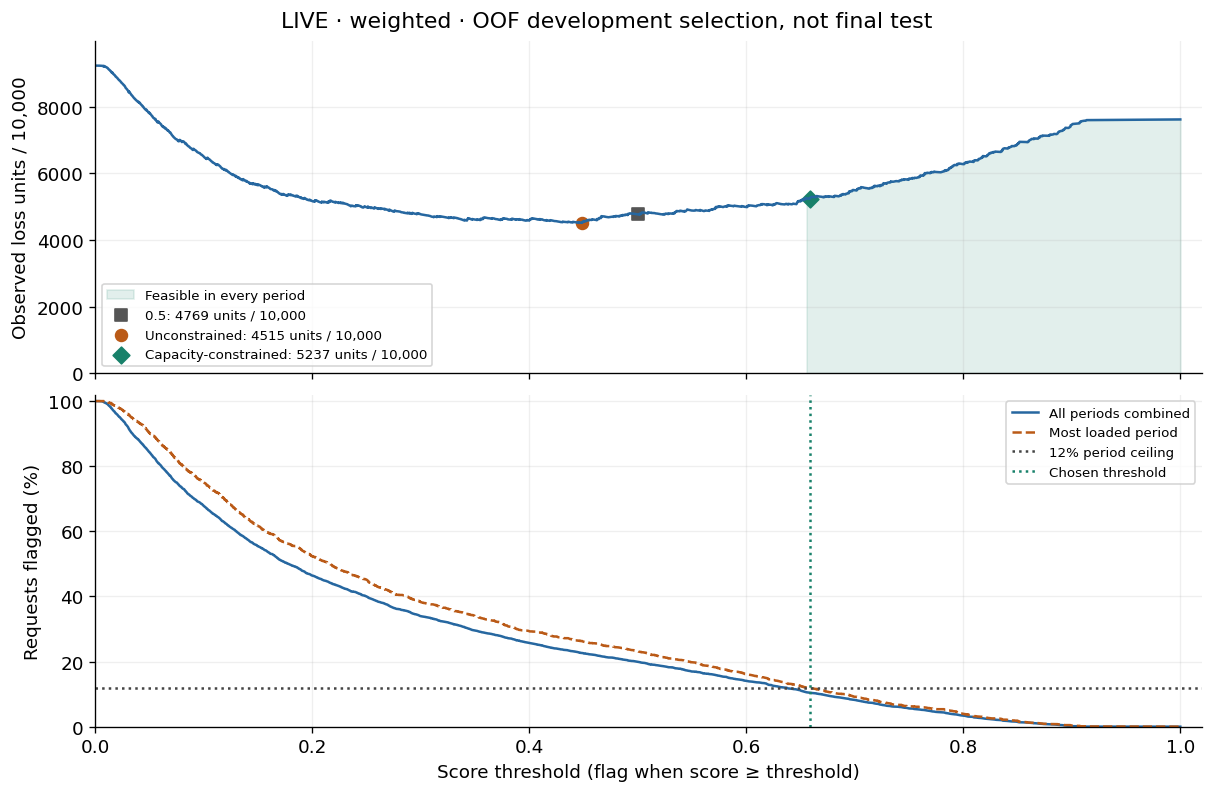

In [58]:
cost_curve = threshold_sweep(selected, policy)
unconstrained = select_threshold(cost_curve, constrained=False)
chosen = select_threshold(cost_curve, constrained=True)
default = cost_curve.loc[cost_curve.threshold.eq(.5)].iloc[0].to_dict()
operating_points = pd.DataFrame([{**point, "rule": name} for name, point in
    [("Default 0.5", default), ("Minimum loss, no capacity limit", unconstrained),
     ("Minimum loss, every-period capacity", chosen)]])
display(operating_points[["rule", "threshold", "tp", "fp", "fn", "tn", "recall", "precision",
    "flagged", "flag_fraction", "loss_units", "loss_units_per_10000", "capacity_feasible"]].round(4))
assert unconstrained["loss_units"] <= default["loss_units"]
if default["capacity_feasible"]:
    assert chosen["loss_units"] <= default["loss_units"]
periods = period_audit(selected, chosen["threshold"], policy)
assert periods.within_capacity.all()
delta = chosen["loss_units"] - default["loss_units"]
print(f"Constrained minus default loss: {delta:+.0f} educational units. Default feasible: {default['capacity_feasible']}")
print("Exact rule to preserve in JSON:", repr(chosen["threshold"]), "with >=")

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, constrained_layout=True)
axes[0].plot(cost_curve.threshold, cost_curve.loss_units_per_10000, color="#2667A0")
axes[0].fill_between(cost_curve.threshold, 0, cost_curve.loss_units_per_10000,
    where=cost_curve.capacity_feasible, color="#18816A", alpha=.12, label="Feasible in every period")
for label, point, marker, color in [("0.5", default, "s", "#555555"),
    ("Unconstrained", unconstrained, "o", "#BA5A17"), ("Capacity-constrained", chosen, "D", "#18816A")]:
    axes[0].scatter([point["threshold"]], [point["loss_units_per_10000"]], marker=marker, color=color, s=50,
        label=f"{label}: {point['loss_units_per_10000']:.0f} units / 10,000")
axes[0].set(ylabel="Observed loss units / 10,000", ylim=(0, cost_curve.loss_units_per_10000.max()*1.08))
axes[0].legend(fontsize=8)
axes[1].plot(cost_curve.threshold, cost_curve.flag_fraction*100, label="All periods combined", color="#2667A0")
axes[1].plot(cost_curve.threshold, cost_curve.max_period_flag_fraction*100, linestyle="--",
    label="Most loaded period", color="#BA5A17")
axes[1].axhline(policy.max_flag_fraction*100, color="#444444", linestyle=":", label="12% period ceiling")
axes[1].axvline(chosen["threshold"], color="#18816A", linestyle=":", label="Chosen threshold")
axes[1].set(xlabel="Score threshold (flag when score ≥ threshold)", ylabel="Requests flagged (%)", ylim=(0,102), xlim=(0,1.02))
axes[1].legend(fontsize=8)
fig.suptitle(f"{SOURCE} · {MODEL_FOR_DECISION} · OOF development selection, not final test")
fig.savefig(ARTIFACTS / "cost_curve.png", dpi=160)
plt.show()

### **6. Audit every period and test policy sensitivity**

We need to check that the selected **threshold** works within the capacity limit for each validation period, and then test whether the decision changes when the **FN** cost assumption changes.

- The selected threshold is within capacity in all three periods: **137**, **183**, and **206** flags respectively.

- We test **FN** costs of 8, 10, and 12, while keeping FP cost at **1** and capacity at **12%.**

- **The threshold remains 0.6583** across all three scenarios, showing that the decision is stable to these changes in **FN** cost.

- The **1/11 ≈ 0.0909** theoretical threshold is not used because it assumes calibrated probabilities and no capacity limit.

- The full threshold precision should be preserved because rounding can change which applications are flagged.

Finally, the selected threshold is feasible in every validation period and remains stable under the tested FN-cost scenarios.


In [59]:
display(periods)
sensitivity_rows = []
for fn_cost in [8., 10., 12.]:
    scenario_policy = replace(policy, false_negative_cost=fn_cost)
    scenario = select_threshold(threshold_sweep(selected, scenario_policy))
    sensitivity_rows.append({"FN_loss_units": fn_cost, "FP_loss_units": policy.false_positive_cost,
        "capacity_fraction": policy.max_flag_fraction, "threshold": scenario["threshold"],
        "flagged": scenario["flagged"], "recall": scenario["recall"],
        "loss_units": scenario["loss_units"], "capacity_feasible": scenario["capacity_feasible"], "source": SOURCE})
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.round(4))
print("Theoretical threshold 1/11 ≈ 0.0909 requires calibrated probabilities, this loss matrix and no capacity limit.")
print("Do not impose that formula on today's weighted raw scores.")

,fold,rows,capacity,flagged,flag_fraction,within_capacity,source
0,1,1632,195,137,0.083946,True,LIVE
1,2,1674,200,183,0.109319,True,LIVE
2,3,1733,207,206,0.118869,True,LIVE


,FN_loss_units,FP_loss_units,capacity_fraction,threshold,flagged,recall,loss_units,capacity_feasible,source
0,8.0,1,0.12,0.6583,526,0.4089,2185.0,True,LIVE
1,10.0,1,0.12,0.6583,526,0.4089,2639.0,True,LIVE
2,12.0,1,0.12,0.6583,526,0.4089,3093.0,True,LIVE


Theoretical threshold 1/11 ≈ 0.0909 requires calibrated probabilities, this loss matrix and no capacity limit.
Do not impose that formula on today's weighted raw scores.


### **7. Report descriptive group differences carefully**

We need to check whether the selected shared threshold produces different results across regions.

- One shared threshold is used for all regions.

- FPR is calculated as false positives ÷ non-default cases.

- We report the non-default denominator, flags, FPR, and recall for each region.

- The FPR gap between the highest and lowest region is 0.6484 percentage points.

- All regions have sufficient non-default cases, so no low-support warning is required.

- This is a descriptive audit only and does not establish statistical significance, legal fairness, or a causal relationship with geography.

The results show some descriptive differences between regions, which should be reviewed, but they should not be interpreted as proof of unfairness or fairness.


,region,rows,negatives,positives,flagged,false_positives,true_positives,false_positive_rate,recall,low_negative_support,source
0,central,1184,1088,96,131,88,43,0.0809,0.4479,False,LIVE
1,western,1262,1158,104,132,96,36,0.0829,0.3462,False,LIVE
2,eastern,1295,1192,103,131,92,39,0.0772,0.3786,False,LIVE
3,other,1298,1217,81,132,93,39,0.0764,0.4815,False,LIVE


FPR gap (percentage points): 0.6484134519182061


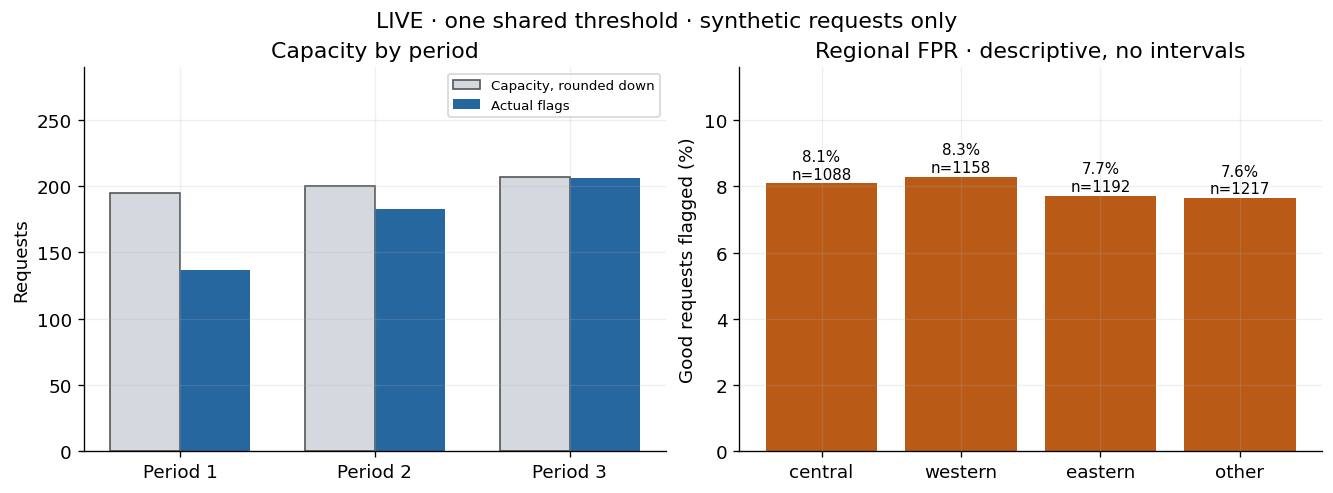

In [60]:
regions, gap_info = region_audit(selected, chosen["threshold"])
display(regions.round(4))
print("FPR gap (percentage points):", gap_info["fpr_gap_percentage_points"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
x = np.arange(len(periods))
axes[0].bar(x-.18, periods.capacity, .36, color="#D3D9DE", edgecolor="#555555", label="Capacity, rounded down")
axes[0].bar(x+.18, periods.flagged, .36, color="#2667A0", label="Actual flags")
axes[0].set(xticks=x, xticklabels=[f"Period {n}" for n in periods.fold], ylabel="Requests", title="Capacity by period")
axes[0].set_ylim(0, periods.capacity.max()*1.4)
axes[0].legend(fontsize=8)
axes[1].bar(regions.region, regions.false_positive_rate*100, color="#BA5A17")
axes[1].set(ylabel="Good requests flagged (%)", title="Regional FPR · descriptive, no intervals")
for i, row in enumerate(regions.itertuples()):
    if pd.notna(row.false_positive_rate):
        axes[1].text(i, row.false_positive_rate*100+.15, f"{row.false_positive_rate:.1%}\nn={row.negatives}", ha="center", fontsize=9)
axes[1].set_ylim(0, max(10, regions.false_positive_rate.max()*140))
fig.suptitle(f"{SOURCE} · one shared threshold · synthetic requests only")
fig.savefig(ARTIFACTS / "day3_capacity_regions.png", dpi=160)
plt.show()

### **8. Write the decision argument yourself**


In [61]:
responses = {"threshold_reason": "The selected threshold was chosen because it gives the lowest loss while satisfying the capacity requirement in every validation period.",
             "cost_capacity_tradeoff": "A lower threshold can identify more defaults but creates more flags. The selected threshold accepts some additional loss to remain within the review capacity.",
             "regional_gap": "The FPR varies across regions, with a gap of 0.6484 percentage points between the highest and lowest region. This is a descriptive difference that should be reviewed, but it does not prove unfairness.",
             "limitations": "This is based on synthetic data and OOF development results. It is not a statistical significance test, legal fairness assessment, or causal analysis.",
             "why_accuracy_misleads": "Accuracy can be high even when the model misses all defaults because defaults are a minority class. Therefore, recall, precision, AP, loss, and capacity should also be considered.",
             "why_oof": "OOF predictions provide predictions for applications that were not used to train the corresponding model, giving a safer estimate of development performance than training predictions."
             }

checkpoint = reflection_check(responses, SOURCE)
print(checkpoint["status"], "| missing:", checkpoint["missing"])

READY_FOR_REVIEW | missing: []


**9. Export the decision card and evidence**


In [62]:
def json_safe(value):
    if isinstance(value, dict): return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)): return [json_safe(v) for v in value]
    if isinstance(value, np.generic): value = value.item()
    if isinstance(value, float) and not np.isfinite(value): return None
    return value

checkpoint = reflection_check(responses, SOURCE)
status = "TECHNICAL_READY" if SOURCE == "LIVE" else "EXAMPLE_ONLY_NOT_SUBMITTABLE"
pooled_ap = float(average_precision_score(selected[TARGET], selected.probability))
threshold_metrics = {"source": SOURCE, "technical_status": status, "strategy": MODEL_FOR_DECISION,
    "policy": asdict(policy), "unit": "educational_loss_unit", "comparison_operator": ">=",
    "capacity_scope": "every validation period; floor(fraction * period_rows)",
    "chosen": chosen, "unconstrained": unconstrained, "default_0_5": default,
    "loss_change_vs_default": delta, "pooled_oof_ap": pooled_ap, "regional_audit": gap_info,
    "coverage": coverage, "selection_status": "OOF development selection; not an independent final test"}
membership = train[["application_id", "application_date"]].copy()
membership["role"], membership["fold"] = "warmup_no_oof", 0
for fold in folds:
    membership.loc[fold["valid"], "role"] = "eligible_oof"
    membership.loc[fold["valid"], "fold"] = fold["audit"]["fold"]
membership["source"] = SOURCE
decisions = selected.copy()
decisions["review_flag"] = flag_at(selected.probability, chosen["threshold"]).astype(int)
csv_outputs = {"day3_model_report.csv": model_report, "day3_model_comparison.csv": comparison,
    "day3_oof_predictions.csv": oof, "day3_oof_coverage.csv": membership, "threshold_sweep.csv": cost_curve,
    "day3_period_capacity.csv": periods, "day3_region_audit.csv": regions,
    "day3_cost_sensitivity.csv": sensitivity, "day3_review_flags.csv": decisions}
for filename, table in csv_outputs.items(): table.to_csv(ARTIFACTS / filename, index=False)
run = {"technical_status": status, "learner_status": checkpoint["status"], "source": SOURCE,
    "requested_config": asdict(config), "effective_config": effective_config, "assessment_mode": ASSESSMENT_MODE,
    "data_revision": COURSE_REVISION, "lab_revision": LAB_REVISION, "support_sha256": SUPPORT_HASHES,
    "day2_revision": DAY2_REVISION, "day2_sha256": DAY2_SHA256, "manifest_sha256": MANIFEST_SHA256,
    "training_data_sha256": hashlib.sha256((ROOT / "data/tamweel_train.csv").read_bytes()).hexdigest(),
    "python": platform.python_version(), "elapsed_seconds": round(time.perf_counter()-RUN_STARTED,2),
    "coverage": coverage, "challenge_used_for_modeling": False, "no_automatic_grade": True}
if IN_COLAB:
    import resource
    run["peak_process_memory_mib"] = round(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss/1024,1)
json_outputs = {"threshold_metrics.json": threshold_metrics, "day3_provenance.json": provenance,
    "day3_reflection.json": {"source": SOURCE, "responses": responses, "checkpoint": checkpoint}, "day3_run.json": run}
for filename, payload in json_outputs.items():
    (ARTIFACTS / filename).write_text(json.dumps(json_safe(payload), ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")

answer = lambda key: responses[key].strip() or "[اكتب تفسيرك من نتائجك هنا]"
rate_text = lambda value: f"{value:.2%}" if pd.notna(value) else "غير معرّفة لغياب المقام"
card_status = ("مثال تعليمي غير صالح للتسليم كتجربة شخصية" if SOURCE != "LIVE" else
               "مسودة — أكمل تفسيرك" if checkpoint["missing"] else "جاهزة للمراجعة؛ لا تعني اعتمادًا أو درجة")
card = f"""# بطاقة قرارك — Tamweel Lite

**الحالة:** {card_status}
**مصدر الأرقام:** {SOURCE} · **الاستراتيجية:** {MODEL_FOR_DECISION} · **الصفوف:** {len(selected):,} OOF

**المهمة:** الفئة الموجبة `default_within_90d=1` تعني حدث تعثر اصطناعي خلال90 يومًا بعد الطلب. كل طية تحقق طلبات لاحقة، وتستبعد عملاءها من التدريب وتشترط نضج نتيجة التدريب قبل بدايتها. المعرّفات والتاريخ خارج المدخلات.

| الدليل | القيمة |
|---|---:|
| العتبة المقيدة، بالقيمة الكاملة | {repr(chosen['threshold'])} |
| عتبة أقل خسارة دون قيد | {repr(unconstrained['threshold'])} |
| Recall | {rate_text(chosen['recall'])} |
| Precision | {rate_text(chosen['precision'])} |
| AP مجمع منOOF | {pooled_ap:.4f} |
| الإشارات | {chosen['flagged']:,} من {len(selected):,} |
| FN / FP | {chosen['fn']} / {chosen['fp']} |
| الخسارة التعليمية | {chosen['loss_units']:.0f} وحدة |
| خسارة0.5 | {default['loss_units']:.0f} وحدة؛ ضمن السعة: {default['capacity_feasible']} |
| التغير عن0.5 | {delta:+.0f} وحدة؛ الموجب زيادة |
| خسارة لكل10,000 طلب، تطبيع حسابي | {chosen['loss_units_per_10000']:.2f} وحدة |
| فجوة معدل الإنذار الخاطئ بين المناطق | {gap_info['fpr_gap_percentage_points']:.3f} نقطة مئوية |

**القاعدة:** درجة ≥ {repr(chosen['threshold'])} تعني إشارة مراجعة داخل التمرين؛ غير ذلك بلا إشارة. لا تتخذ موافقة أو رفض تمويل حقيقي. احفظ الدقة الكاملة؛ تقريب العتبة قد يغيّر حجم الطابور.

**السياسة:** FN={policy.false_negative_cost:g} وFP={policy.false_positive_cost:g} وحدات تعليمية، وسعة {policy.max_flag_fraction:.0%} لكل فترة بعد التقريب لأسفل. ليست ريالات فعلية أو رسوم أدوات أو خصمًا من الدرجة.

**دليل السعة:** {', '.join(f"الفترة {int(row.fold)}: {int(row.flagged)}/{int(row.capacity)}" for row in periods.itertuples())}.

## لماذا اخترت هذه العتبة؟
{answer('threshold_reason')}

## الخسارة والسعة
{answer('cost_capacity_tradeoff')}

## فرق المناطق وما يحتاج إلى مراجعة
{answer('regional_gap')}

## حدود النتيجة
{answer('limitations')}

OOF تغطي {coverage['whole_data_coverage']:.2%} من التدريب و100% من الصفوف المؤهلة؛ {coverage['warmup_without_oof']:,} صفًا تمهيديًا بلا تنبؤ. اختيار العتبة وتقدير خسارتها هنا يستخدمان أهدافOOF نفسها؛ هذه نتيجة تطوير لا اختبار نهائي. لم نستخدم التحدي. المقارنة الجغرافية وصفية وليست شهادة عدالة، والأوزان لا تضمن معايرة الدرجات.

## سؤالك الأول: لماذا قد تخدعكAccuracy؟
{answer('why_accuracy_misleads')}

## سؤالك الثاني: لماذا تختار علىOOF؟
{answer('why_oof')}

أدلتك في `artifacts/threshold_metrics.json` و`day3_period_capacity.csv` و`day3_region_audit.csv` و`day3_cost_sensitivity.csv` و`cost_curve.png`. الحساسية سيناريوهات ±20% لخسارةFN، وليست فترات ثقة. راجع السعة والمعايرة عند تغير البيانات؛ لا تفترض ثباتهما مستقبلًا.
"""
(REPORTS / "DECISION_CARD.md").write_text(card, encoding="utf-8")
artifact_files = list(csv_outputs) + list(json_outputs) + ["cost_curve.png", "day3_roc_pr.png", "day3_capacity_regions.png", "environment.json"]
with zipfile.ZipFile(ARTIFACTS / "day3_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as bundle:
    for filename in artifact_files:
        bundle.write(ARTIFACTS / filename, "artifacts/" + filename)
    bundle.write(REPORTS / "DECISION_CARD.md", "reports/DECISION_CARD.md")
print(f"{status} | {checkpoint['status']} | {SOURCE} | {run['elapsed_seconds']} seconds | CPU")
print(f"Saved {len(artifact_files)+1} files in day3_artifacts.zip — complete your reasoning and download.")

TECHNICAL_READY | READY_FOR_REVIEW | LIVE | 98.98 seconds | CPU
Saved 18 files in day3_artifacts.zip — complete your reasoning and download.


# Day 4 · Explain the model and test its probabilities


### **1. Prepare a controlled environment**


In [63]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
PREVIOUS_SUPPORT = {
    "scripts/day2_validation.py": ("1e1da4acbee8941bef07245b259fb6c27ced4ad7", "d2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43"),
    "scripts/day3_decision.py": ("c2dc52e129878d0d487db1874891c658de7c4d0d", "40f176633c91fc530db222978bc44495a401b888b1ce448728948f7ae0ca9e12")}
for relative, (revision, digest) in PREVIOUS_SUPPORT.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{revision}/{relative}", ROOT / relative, digest)
LAB_REVISION = "4f6892d5c02923b5f8e3c78f4fcead73b043570f"
SUPPORT_HASHES = {'scripts/day4_trust.py': '7e0f54bdbed94b28d09cddd02ce0ba0471d5046f05c7b70589e3e4be9902f20c', 'data/day4_shap_example.npz': 'de6eefb4f0b1dfd54d4a71e2b73cf8383cea6386e661f8af8662d478cd957e2b', 'data/day4_shap_example.json': '8169c70dc327a7ffdff748c365d71544fe951f3b196974e33f09dccb580a8122'}
for relative, digest in SUPPORT_HASHES.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}", ROOT / relative, digest)
print("Day 4 setup verified | إعداد اليوم الرابع جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 4 setup verified | إعداد اليوم الرابع جاهز


### **2. Separate fit, calibration, policy and evaluation**

I separated the data into four roles to prevent data leakage:

- **Fit**: 2,516 rows — used to train the model.

- **Calibration**: 584 rows — used only for probability calibration.

- **Policy**: 589 rows — used to select the threshold under the 12% capacity limit and the 10×FN + FP cost.

- **Evaluation**: 1,733 rows — used only to evaluate the frozen model.

A total of **4,578** rows were excluded because of gaps or conflicting customer assignments.

I used FAST mode with 80 trees, **300** SHAP rows, **3** permutation repeats, and 200 bootstrap replicates.

The model, calibration, and policy threshold **were frozen before evaluatio**n, so the evaluation data was not used for training or tuning.


In [64]:
import json, platform, zipfile
from dataclasses import asdict
import numpy as np
import pandas as pd
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from scipy.special import expit
from IPython.display import display
from data_checks import validate_frame
from day2_validation import deduplicate_applications
from day4_trust import (TARGET, ROLES, TrustConfig, split_roles, fit_and_calibrate,
    probability_metrics, reliability_table, permutation_report, explain_sample, load_shap_example,
    ShapBudgetExpired, reason_codes, local_stability, cluster_bootstrap, choose_policy_threshold,
    transport_threshold, map_probability, review_audit, reflection_check)

contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
train, duplicates = deduplicate_applications(pd.read_csv(ROOT / "data/tamweel_train.csv"))
validate_frame(train, contract, "train")
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE
config = TrustConfig() if FAST_MODE else TrustConfig(trees=160, shap_rows=600, permutation_repeats=5, bootstrap_repeats=500)
USE_SHAP_EXAMPLE = False  # Discussion only; not a personal submission.
ASSESSMENT_MODE = os.environ.get("ASSESSMENT_MODE", "0") == "1"
ARTIFACTS, REPORTS = ROOT / "artifacts", ROOT / "reports"
ARTIFACTS.mkdir(exist_ok=True); REPORTS.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
parts, assignments = split_roles(train)
role_summary = pd.DataFrame([{"role": r, "rows": len(p), "customers": p.customer_id.nunique(),
    "positives": int(p[TARGET].sum()), "positive_rate": p[TARGET].mean(),
    "first_date": p.application_date.min(), "last_date": p.application_date.max()} for r, p in parts.items()])
display(role_summary)
print("Excluded gaps/customer overlaps:", int((assignments.role == "excluded_gap_or_customer").sum()))
model, calibrated_model, predictions, provenance = fit_and_calibrate(parts, contract, config)
evaluation = predictions[predictions.role == "evaluation"].copy()
policy_rows = predictions[predictions.role == "policy"].copy()
chosen_policy, policy_sweep = choose_policy_threshold(policy_rows)
mapping = provenance["calibration_mapping"]
calibrated_threshold = transport_threshold(chosen_policy["threshold"], mapping)
print("Model, sigmoid and policy threshold frozen before evaluation.")

,role,rows,customers,positives,positive_rate,first_date,last_date
0,fit,2516,1853,217,0.086248,2022-01-01,2023-04-01
1,calibration,584,538,40,0.068493,2023-07-01,2023-09-30
2,policy,589,566,55,0.093379,2024-01-01,2024-03-31
3,evaluation,1733,1520,139,0.080208,2024-07-01,2024-12-31


Excluded gaps/customer overlaps: 4578
Model, sigmoid and policy threshold frozen before evaluation.


### **3. Measure held-out dependence with permutation importance**

Permutation feature importance provides a realistic, robust measurement of what the model has actually learned by comparing the **Training Split Gain** (what the model relied on during training) against the **Held-Out Average Precision (AP)**. **Drop** (the impact on unseen validation data when a feature is randomized).

Based on our executed run on the evaluation dataset ($n = 1,733$$n = 1,733$ requests):

**1. The Core Drivers: bureau_score and dti (Debt-to-Income)**

- `bureau_score` is the most critical feature in the entire system. It has the highest training split gain (approaching 9,000 units) and its permutation causes the largest drop in held-out Average Precision ($ approx 0.127$$ approx 0.127$). Shuffling this column degrades model performance by nearly 13 percentage points, confirming it holds genuine, non-redundant predictive signal.

- `dti` is the second most important feature. It has a high training split gain ($ approx 6,400$$ approx 6,400$) and its randomization drops the held-out AP by approximately $0.07$$0.07$ (7 percentage points).

**2. The Behavior of Correlated Features (e.g., Credit Obligations & Savings)**

- Features like `loan_amount_sar`, `savings_balance_sar`, and `existing_obligations_sar` show moderate training split gains but lead to very small drops in held-out AP (typically $< 0.015$$< 0.015$) when permuted.

- **Why this happens:** Tree-based models (like LightGBM) can easily substitute correlated features for one another. If we permute loan_amount_sar, the model still retains access to highly correlated signals (such as `existing_obligations_sar` or `income_sar`) to make its predictions. Therefore, the performance drop is small even though these features are heavily utilized during training.

**3. Low-Impact Features**

- Features such as `recent_inquiries` and `months_employed` have negligible impacts on held-out AP, with confidence intervals (standard deviation bars from repeats) crossing zero. This indicates that while they may have been used to make minor splits during training, they provide virtually no generalizable predictive value on unseen data.


,feature_group,mean_ap_drop,repeat_sd,training_gain
0,bureau_score,0.1270,0.0235,8922.6701
1,dti,0.0690,0.0200,6423.5164
2,loan_amount_sar,0.0140,0.0095,2372.2859
3,savings_balance_sar,0.0094,0.0032,2129.8893
4,prior_defaults,0.0065,0.0021,1109.2766
5,recent_inquiries,0.0064,0.0089,902.9509
6,income_sar,0.0062,0.0058,2214.5619
7,utilization_ratio,0.0057,0.0011,2035.9451
8,region_indicators_joint,0.0047,0.0020,360.9725
9,months_employed,0.0025,0.0044,2482.2264


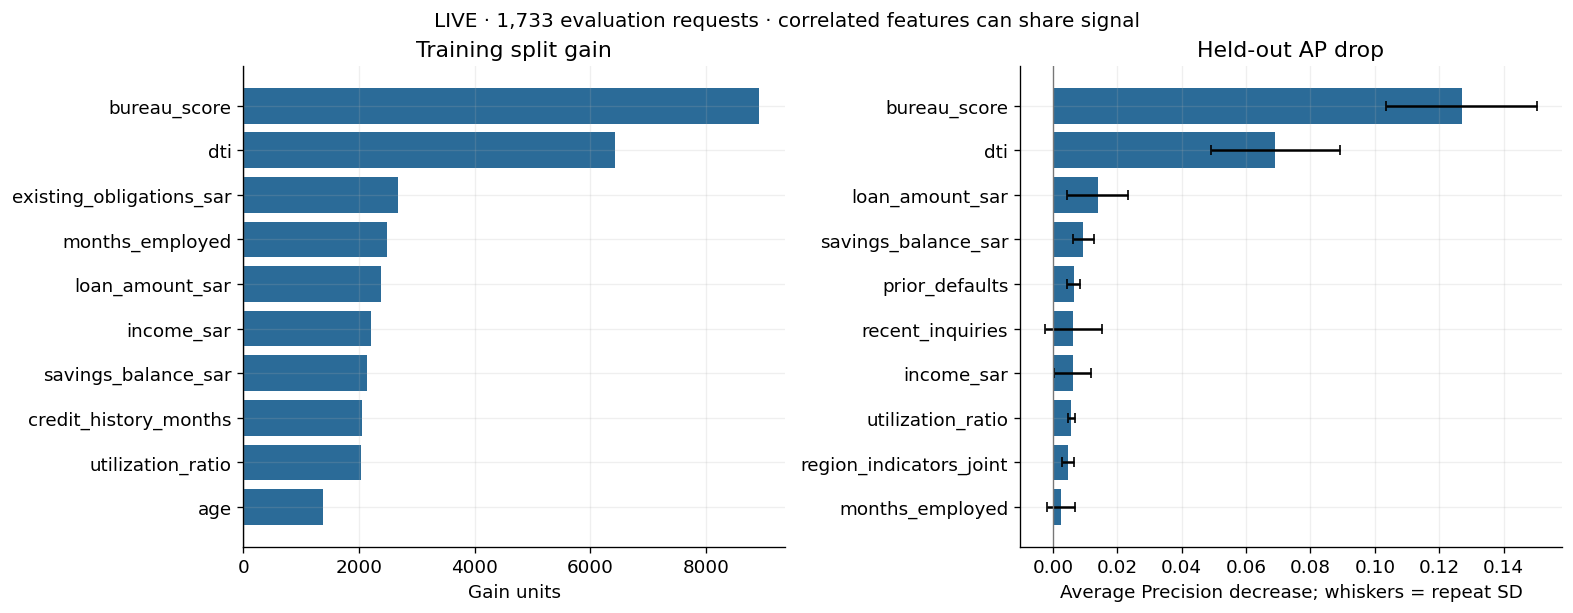

In [65]:
permutation = permutation_report(model, parts["evaluation"], contract, config)
display(permutation[["feature_group", "mean_ap_drop", "repeat_sd", "training_gain"]].head(10).round(4))
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
for ax, value, title in [(axes[0], "training_gain", "Training split gain"), (axes[1], "mean_ap_drop", "Held-out AP drop")]:
    top = permutation.nlargest(10, value).sort_values(value)
    ax.barh(top.feature_group, top[value], color="#2b6b98",
            xerr=top.repeat_sd if value == "mean_ap_drop" else None, capsize=3)
    ax.axvline(0, color="#777", lw=.8); ax.set_title(title)
    ax.set_xlabel("Gain units" if value == "training_gain" else "Average Precision decrease; whiskers = repeat SD")
fig.suptitle(f"LIVE · {len(evaluation):,} evaluation requests · correlated features can share signal", fontsize=12)
fig.savefig(ARTIFACTS / "permutation_importance.png", bbox_inches="tight"); plt.show()

### **4. Read the global SHAP explanation and its unit**

- **Unit of Measurement:** SHAP values are measured in **raw log-odds** of the uncalibrated model (base value $\approx -1.79$), not probability points. They are additive on the log-odds scale, and mapped to probability using the sigmoid function: $\text{sigmoid}(\text{base} + \sum \text{SHAP})$.

- **Beaswarm Plot 4-Step Summary:**
  1. **Rank:** `bureau_score` (mean absolute SHAP $\approx 0.90$) and `dti` ($\approx 0.54$) are the most influential variables, followed by `loan_amount_sar` and `savings_balance_sar`.
  2. **Sign:** High `bureau_score` and high `savings_balance` decrease default risk (negative SHAP), whereas high `dti` and having `prior_defaults` significantly increase risk (positive SHAP).
  3. **Colour:** High feature values (red) align logically with their economic risk direction; for example, high savings (red) lower risk, while high DTI (red) increases risk.
  4. **Spread:** `bureau_score` shows a long right-tail of blue dots (low scores), indicating that poor credit history triggers disproportionately high risk penalties.


,feature,mean_absolute_shap_log_odds
4,bureau_score,0.9042
5,dti,0.5437
2,loan_amount_sar,0.3490
10,savings_balance_sar,0.2169
9,existing_obligations_sar,0.2022
8,prior_defaults,0.1830
6,months_employed,0.1584
1,income_sar,0.1549
7,recent_inquiries,0.1492
13,utilization_ratio,0.1287


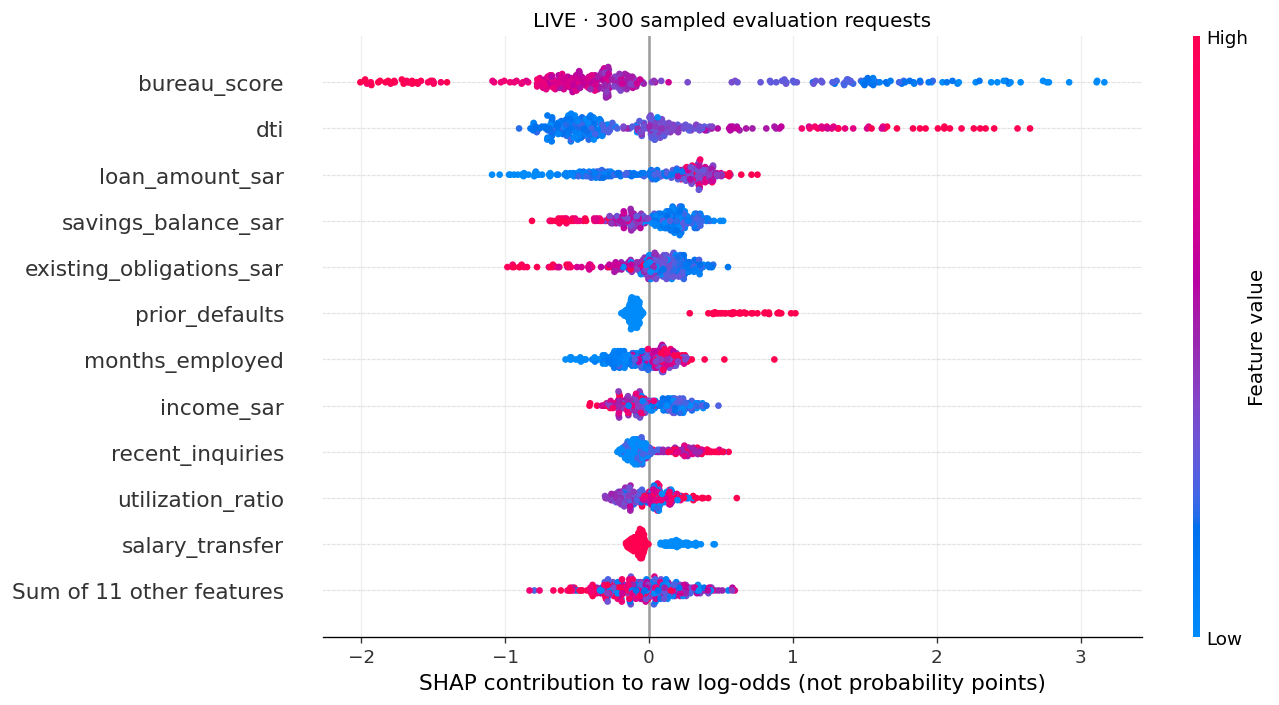

Maximum additivity error: 5.6968318951078345e-15


In [66]:
try:
    if USE_SHAP_EXAMPLE:
        raise ShapBudgetExpired("Educational example requested.")
    shap_arrays, shap_metadata = explain_sample(model, parts["evaluation"], contract, config)
except ShapBudgetExpired:
    shap_arrays, shap_metadata = load_shap_example(ROOT / "data/day4_shap_example.npz",
        ROOT / "data/day4_shap_example.json", model, parts["evaluation"], contract, ASSESSMENT_MODE)

import shap
EXPLANATION_SOURCE = shap_metadata["source"]
if EXPLANATION_SOURCE != "LIVE":
    print("EDUCATIONAL_EXAMPLE — مثال موسوم للمناقشة، غير صالح للتسليم كتجربتك. أعد SHAP لاحقًا.")
explanation = shap.Explanation(values=shap_arrays["values"], base_values=shap_arrays["base_values"],
    data=shap_arrays["data"], feature_names=list(shap_arrays["feature_names"]))
shap_global = pd.DataFrame({"feature": shap_arrays["feature_names"],
    "mean_absolute_shap_log_odds": np.abs(shap_arrays["values"]).mean(axis=0)}).sort_values("mean_absolute_shap_log_odds", ascending=False)
display(shap_global.head(10).round(4))
plt.figure()
shap.plots.beeswarm(explanation, max_display=12, show=False, plot_size=(11, 6.5))
plt.xlabel("SHAP contribution to raw log-odds (not probability points)")
plt.title(f"{EXPLANATION_SOURCE} · {len(shap_arrays['application_ids'])} sampled evaluation requests", fontsize=12)
plt.savefig(ARTIFACTS / "shap_beeswarm.png", bbox_inches="tight"); plt.show()
print("Maximum additivity error:", shap_metadata["max_additivity_error"])

### **5. Explain one high-score synthetic request (TR-009585)**

We explain the synthetic request **TR-009585**, which has the highest raw model score ($0.9031$) in our SHAP sample, resulting in a calibrated default probability of **$47.95\%$**.

- **Base Value vs. Final Score:** The model begins at a base log-odds of **$-1.79$**. Cumulative feature contributions increase this raw margin by $+4.02$ log-odds, bringing the final raw margin to **$+2.23$**.
- **Top Contributing Features:**
  1. **`bureau_score` (497):** Adds **$+2.27$** log-odds. The low credit score is the primary reason for the elevated default risk estimate.
  2. **`dti` (1.281):** Adds **$+1.20$** log-odds. A debt-to-income ratio exceeding $100\%$ heavily penalizes the applicant.
  3. **`loan_amount_sar` (93,437.29):** Adds **$+0.20$** log-odds.
- **Imputation Check:** Both `bureau_score` and `dti` are actual values provided by the applicant (**`was_imputed = False`**). No critical driving variables were synthetic replacements for missing data.
- **Local Stability Check ($\_score \pm 1$):** Perturbing the credit score by $\pm 1$ point (testing scores of 496 and 498) results in a completely stable raw prediction ($0.9031$) and identical top SHAP reasons. This confirms that small marginal changes do not alter the risk rank or trigger unpredictable model sensitivity for this applicant. However, this narrow local check does not guarantee stability for other features or future periods.


TR-009585 | raw score=0.9031 | calibrated probability=0.4795


,feature,value_used,was_imputed,contribution_log_odds,reason_ar
0,bureau_score,497.0000,False,2.269325,استخدم النموذج درجة ائتمانية اصطناعية عند الطل...
1,dti,1.2806,False,1.198145,استخدم النموذج نسبة الالتزام مع القسط المقترح ...
2,loan_amount_sar,93437.2900,False,0.200725,استخدم النموذج مبلغ التمويل المطلوب بالقيمة 93...


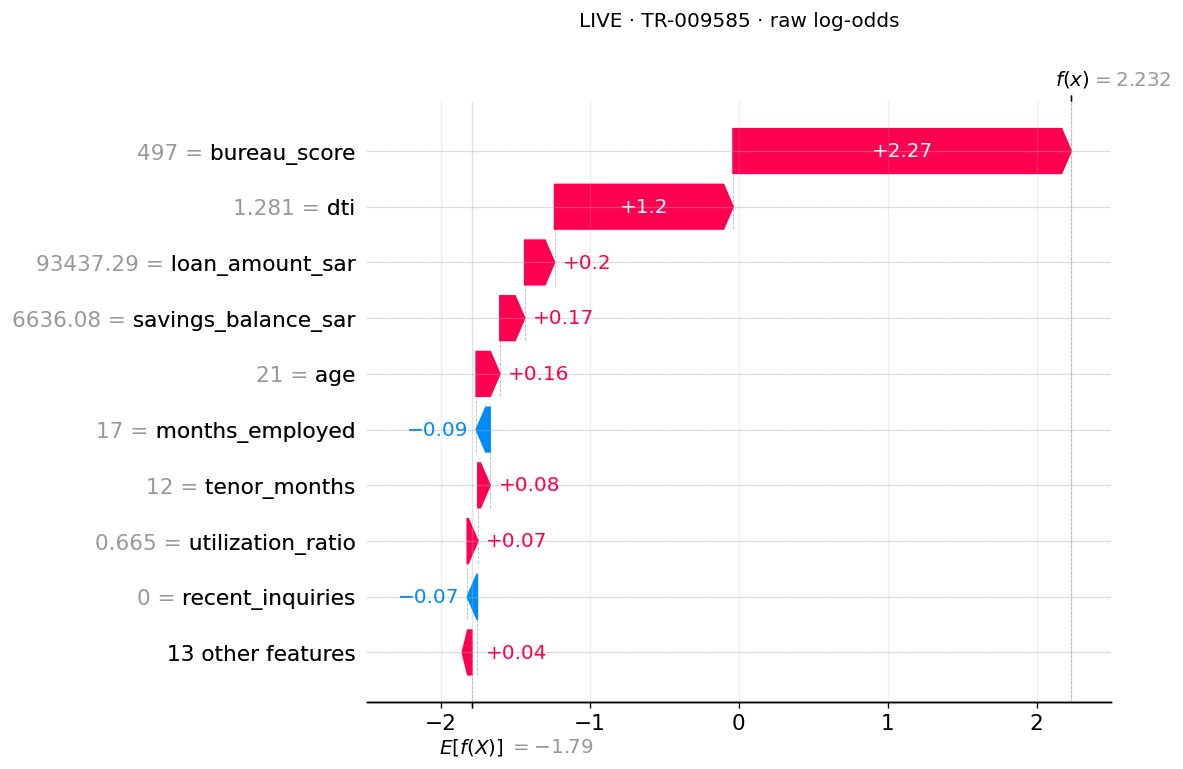

,perturbation,bureau_score_used,raw_probability,calibrated_probability,top_positive_features,shared_top_reasons,reference_reasons,source
0,bureau_score +0,497.0,0.903079,0.479518,bureau_score|dti|loan_amount_sar,3,3,LIVE
1,bureau_score -1,496.0,0.903079,0.479518,bureau_score|dti|loan_amount_sar,3,3,LIVE
2,bureau_score +1,498.0,0.903079,0.479518,bureau_score|dti|loan_amount_sar,3,3,LIVE


In [67]:
local_index = int(np.argmax(shap_arrays["raw_margin"]))
local_id = str(shap_arrays["application_ids"][local_index])
case = parts["evaluation"].set_index("application_id", drop=False).loc[[local_id]]
descriptions = {f["name"]: f["description_ar"] for f in contract["features"]}
reasons = reason_codes(shap_arrays["values"][local_index], shap_arrays["feature_names"],
    shap_arrays["data"][local_index], descriptions)
reasons["application_id"] = local_id
reasons["was_imputed"] = [bool(case.iloc[0][feature] != case.iloc[0][feature]) for feature in reasons.feature]
reasons["source"] = EXPLANATION_SOURCE
raw_local = float(expit(shap_arrays["raw_margin"][local_index]))
cal_local = float(map_probability(raw_local, mapping))
print(f"{local_id} | raw score={raw_local:.4f} | calibrated probability={cal_local:.4f}")
display(reasons[["feature", "value_used", "was_imputed", "contribution_log_odds", "reason_ar"]])
plt.figure()
shap.plots.waterfall(explanation[local_index], max_display=10, show=False)
plt.title(f"{EXPLANATION_SOURCE} · {local_id} · raw log-odds", fontsize=12, pad=45)
plt.savefig(ARTIFACTS / "shap_waterfall.png", bbox_inches="tight"); plt.show()
if EXPLANATION_SOURCE == "LIVE":
    local_checks = local_stability(model, case, contract, mapping)
    local_checks["source"] = "LIVE"
    display(local_checks)
else:
    local_checks = pd.DataFrame(columns=["perturbation", "bureau_score_used", "raw_probability", "calibrated_probability",
        "top_positive_features", "shared_top_reasons", "reference_reasons", "source"])
    print("Local perturbation check skipped in example mode; do not claim it ran.")

### **6. Test calibration on a separate period**

We evaluated the frozen LightGBM model and Sigmoid calibrator (learned on the calibration rows only, without new class weights) against the unseen evaluation dataset ($n = 1,733$ requests, $139$ positives).

- **Ranking vs. Probability Quality Metrics:**
  - **Ranking (Unchanged):** Both the raw and sigmoid-calibrated predictions yielded an identical **ROC-AUC of $0.77080$** and **Average Precision (AP) of $0.25868$**. This is because Platt scaling applies a single monotone sigmoid mapping $P = \text{sigmoid}(a \cdot S + b)$ which preserves the exact risk ordering of applicants.
  - **Probability Quality (Significantly Improved):** The **Brier score** decreased from **$0.11303$ to $0.06711$** (a decrease of $-0.04592$), and **log-loss** dropped from **$0.35799$ to $0.25203$** (a decrease of $-0.10596$). A lower Brier score indicates better-calibrated probability assignments, though it does not automatically prove perfect calibration.
  - **Expected Calibration Error (ECE):** The **ECE** decreased from **$0.14687$ to $0.02249$** (a decrease of $-0.12438$).

- **Reliability Curve & Bin Analysis:**
  - Using ten equal-width bins, the sigmoid-calibrated curve closely tracks the $45^\circ$ ideal agreement line.
  - For the calibrated model, the lower-risk bins are highly populated (e.g., $1,410$ cases in the $0.0\text{--}0.1$ bin), showing stable observed default rates. Conversely, higher-risk bins are extremely sparse (e.g., only $30$ cases in the $0.4\text{--}0.5$ bin and empty bins above $0.5$). Since ECE is weighted by bin counts, these sparse bins represent weaker evidence, indicating that calibration quality checks are naturally more volatile at the higher end due to small sample size.


,rows,positives,roc_auc,average_precision,brier,ece,log_loss
raw,1733,139,0.770804,0.258677,0.113027,0.146871,0.357993
sigmoid,1733,139,0.770804,0.258677,0.067112,0.022486,0.246749


Measured change (after - before): Brier -0.04592, ECE -0.12438


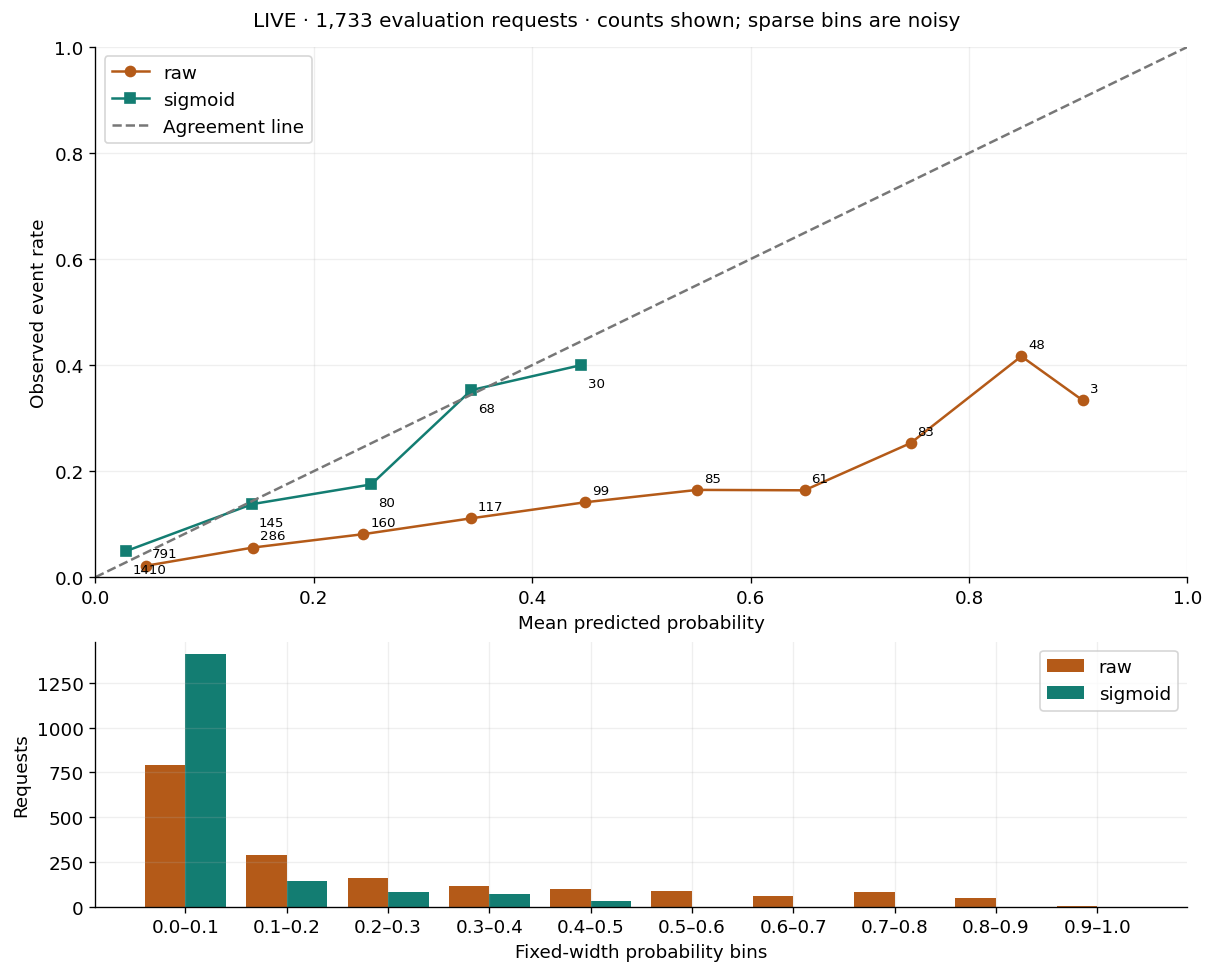

In [68]:
calibration_metrics, bin_tables = {}, []
for label, column in [("raw", "raw_probability"), ("sigmoid", "calibrated_probability")]:
    calibration_metrics[label] = probability_metrics(evaluation[TARGET], evaluation[column])
    table = reliability_table(evaluation[TARGET], evaluation[column]); table["variant"] = label
    bin_tables.append(table)
reliability = pd.concat(bin_tables, ignore_index=True)
display(pd.DataFrame(calibration_metrics).T[["rows", "positives", "roc_auc", "average_precision", "brier", "ece", "log_loss"]].round(5))
brier_delta = calibration_metrics["sigmoid"]["brier"] - calibration_metrics["raw"]["brier"]
ece_delta = calibration_metrics["sigmoid"]["ece"] - calibration_metrics["raw"]["ece"]
print(f"Measured change (after - before): Brier {brier_delta:+.5f}, ECE {ece_delta:+.5f}")
fig, axes = plt.subplots(2, 1, figsize=(10, 8), layout="constrained", gridspec_kw={"height_ratios": [2, 1]})
for label, color, marker in [("raw", "#b45a18", "o"), ("sigmoid", "#137d72", "s")]:
    bins = reliability[reliability.variant == label]; nonempty = bins[bins['count'] > 0]
    axes[0].plot(nonempty.mean_probability, nonempty.observed_rate, marker=marker, color=color, label=label)
    for row in nonempty.itertuples():
        axes[0].annotate(str(row.count), (row.mean_probability, row.observed_rate), xytext=(4, 5 if label == "raw" else -13), textcoords="offset points", fontsize=8)
    positions = bins['bin'] + (-.2 if label == "raw" else .2)
    axes[1].bar(positions, bins['count'], width=.4, color=color, label=label)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="#777", label="Agreement line")
axes[0].set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean predicted probability", ylabel="Observed event rate")
axes[0].legend(); axes[0].grid(alpha=.2)
axes[1].set(xticks=np.arange(10), xticklabels=[f"{i/10:.1f}–{(i+1)/10:.1f}" for i in range(10)], ylabel="Requests", xlabel="Fixed-width probability bins")
axes[1].legend()
fig.suptitle(f"LIVE · {len(evaluation):,} evaluation requests · counts shown; sparse bins are noisy", fontsize=12)
fig.savefig(ARTIFACTS / "reliability_curve.png", bbox_inches="tight"); plt.show()

### **7. Quantify what the stability interval does and does not cover**

- **How the Bootstrap works:** The paired bootstrap draws $200$ replicates by sampling customers rather than single requests, ensuring that any correlated applications from the same customer remain together. It reports 95% percentile intervals for AP and Brier change on the evaluation dataset.

- **What the Interval Covers:**
  - It quantifies the statistical uncertainty arising from **evaluation sample representation** (the specific mix of customers in our $1,733$ evaluation rows).
  - It provides tight empirical bounds showing that our ranking quality (uncalibrated AP 95% interval: $[0.19744, 0.33785]$ vs. calibrated AP: $[0.19744, 0.33785]$) is highly stable, and probability calibration remains robustly superior (Brier change interval is strictly negative, indicating consistent improvement).

- **What the Interval Does NOT Cover:**
  - **Fixed Components:** The model parameters and calibrator mapping coefficients were held completely frozen. The interval therefore **excludes uncertainty from model training, calibration fitting, and feature choice**.
  - **Temporal/Systemic Changes:** It does not capture future credit-score inflation, macroeconomic shifts, or temporal drift.
  - **Not for Individuals:** It describes the aggregate stability of the evaluation metrics, **not** a confidence interval for an individual applicant’s default probability.

- **Quarterly Metrics:** The Q3 and Q4 2024 evaluations describe historical temporal variation in performance. They represent descriptive snapshots, **not** three independent validation folds or a confidence interval. Any change designed after viewing these evaluation periods requires completely new evidence.


,period,variant,rows,positives,average_precision,brier,ece
0,2024Q3,raw,836,78,0.27457,0.11528,0.13397
1,2024Q3,sigmoid,836,78,0.27457,0.07760,0.03229
2,2024Q4,raw,897,61,0.27050,0.11093,0.15890
3,2024Q4,sigmoid,897,61,0.27050,0.05734,0.02434


Paired customer-cluster 95% percentile intervals:


,lower,upper
raw_ap,0.197442,0.337854
calibrated_ap,0.197442,0.337854
brier_change,-0.054177,-0.037409


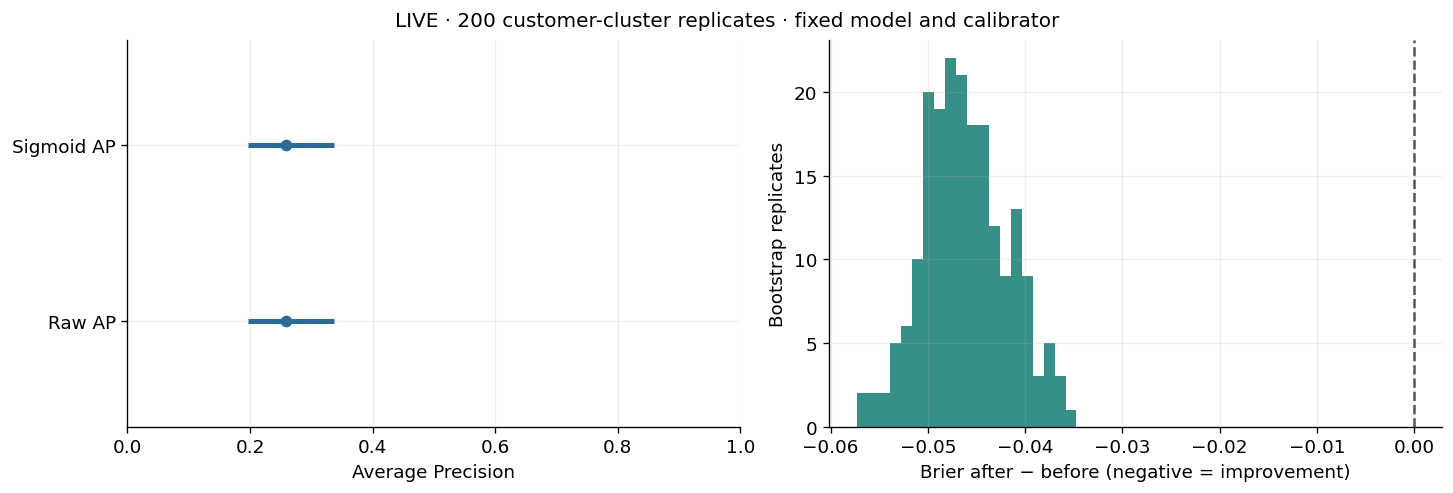

In [69]:
bootstrap, stability_summary = cluster_bootstrap(evaluation, config)
period_rows = []
for period, group in evaluation.groupby(pd.to_datetime(evaluation.application_date).dt.to_period("Q").astype(str)):
    for variant, column in [("raw", "raw_probability"), ("sigmoid", "calibrated_probability")]:
        period_rows.append({"period": period, "variant": variant, **probability_metrics(group[TARGET], group[column])})
period_metrics = pd.DataFrame(period_rows)
display(period_metrics[["period", "variant", "rows", "positives", "average_precision", "brier", "ece"]].round(5))
stability_summary["period_ap_sample_sd"] = {v: float(g.average_precision.std(ddof=1)) for v, g in period_metrics.groupby("variant")}
print("Paired customer-cluster 95% percentile intervals:")
display(pd.DataFrame({key: stability_summary[key] for key in ("raw_ap", "calibrated_ap", "brier_change")}).T)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for i, key in enumerate(("raw_ap", "calibrated_ap")):
    interval = stability_summary[key]
    point = calibration_metrics["raw" if i == 0 else "sigmoid"]["average_precision"]
    if interval is not None:
        axes[0].hlines(i, interval["lower"], interval["upper"], color="#2b6b98", lw=3)
    axes[0].plot(point, i, "o", color="#2b6b98")
axes[0].set(yticks=[0, 1], yticklabels=["Raw AP", "Sigmoid AP"], xlabel="Average Precision", xlim=(0, 1), ylim=(-.6, 1.6))
axes[1].hist(bootstrap.brier_change, bins=20, color="#137d72", alpha=.85)
axes[1].axvline(0, color="#555", linestyle="--"); axes[1].set(xlabel="Brier after − before (negative = improvement)", ylabel="Bootstrap replicates")
fig.suptitle(f"LIVE · {stability_summary['valid']} customer-cluster replicates · fixed model and calibrator", fontsize=12)
fig.savefig(ARTIFACTS / "stability_summary.png", bbox_inches="tight"); plt.show()

### **8. Test whether the review zone fits capacity**

- **Threshold Selection & Transport:**
  - Raw score threshold $0.58820$ was selected on the **policy role** under the educational loss policy ($10\times\text{FN} + \text{FP}$) and a strict $12\%$ period capacity ceiling.
  - This was mapped via monotone sigmoid calibrator to a probability threshold of **$0.17331$**, preserving risk ranking without any reselection on the evaluation set.

- **Diagnostic Band ($\pm 0.02$):**
  - The $[0.15331, 0.19331]$ region serves as a diagnostic boundary margin for borderline cases, not individual confidence intervals. To assess total workload, the union of risk-flagged and near-threshold cases is counted once (no double-counting).

- **Evaluation Period Audit Results:**
  - **Q3 2024:** Raw risk flags accounted for $97$ cases (under the $100$ capacity limit). Adding $23$ near-threshold cases resulted in a union of **$109$** candidate reviews, exceeding capacity.
  - **Q4 2024:** Raw risk flags alone reached $109$ cases, exceeding the $107$ capacity limit before even considering near-threshold cases. Adding near-threshold cases pushed the union to **$122$** candidate reviews.

- **Operational Conclusion (`CAPACITY_REVIEW_REQUIRED`):**
  - This capacity violation is a crucial finding highlighting model drift or expanding risk. Following standard practice, we do not adjust the ceiling post-hoc or retune the threshold on evaluation data. If operational capacity is rigid, a revised policy threshold must be systematically redesigned on a separate training/policy split.


,threshold,flagged,fn,fp,loss_units,capacity,feasible,calibrated_threshold,selection_role
0,0.588195,68,34,47,387.0,70,True,0.17331,policy


,period,rows,capacity,risk_flags,near_threshold,candidate_review,risk_within_capacity,candidate_within_capacity,loss_units
0,2024Q3,836,100,97,23,109,True,False,536.0
1,2024Q4,897,107,109,21,122,False,False,444.0


CAPACITY_REVIEW_REQUIRED | Do not retune on evaluation.


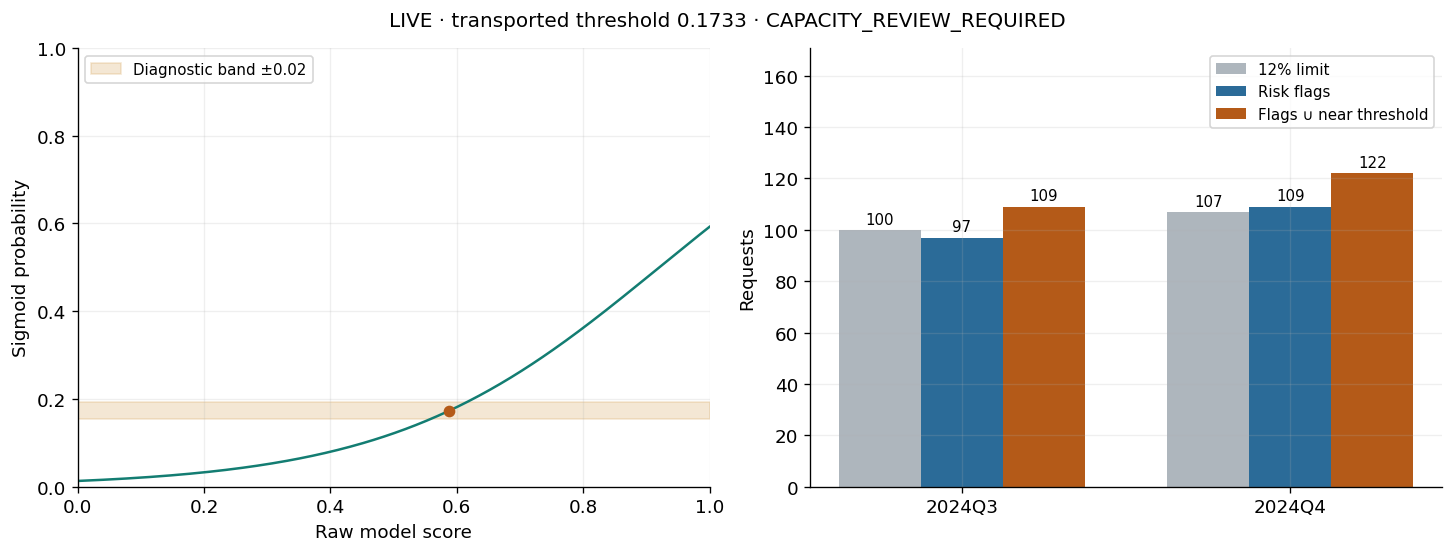

In [70]:
review_flags, capacity_audit, review_band = review_audit(evaluation, chosen_policy["threshold"],
    calibrated_threshold, config.review_half_width)
policy_status = "CAPACITY_REVIEW_REQUIRED" if not capacity_audit.candidate_within_capacity.all() else "WITHIN_OBSERVED_CAPACITY"
display(pd.DataFrame([{**chosen_policy, "calibrated_threshold": calibrated_threshold, "selection_role": "policy"}]))
display(capacity_audit)
print(policy_status, "| Do not retune on evaluation.")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
grid = np.linspace(0, 1, 300)
axes[0].plot(grid, map_probability(grid, mapping), color="#137d72")
axes[0].axhspan(review_band['lower'], review_band['upper'], color="#d7a354", alpha=.25, label="Diagnostic band ±0.02")
axes[0].plot(chosen_policy['threshold'], calibrated_threshold, 'o', color="#b45a18")
axes[0].set(xlim=(0, 1), ylim=(0, 1), xlabel="Raw model score", ylabel="Sigmoid probability")
axes[0].legend(loc="upper left", fontsize=9)
x = np.arange(len(capacity_audit))
for offset, column, label, color in [(-.25, 'capacity', '12% limit', '#aeb6bd'), (0, 'risk_flags', 'Risk flags', '#2b6b98'), (.25, 'candidate_review', 'Flags ∪ near threshold', '#b45a18')]:
    bars = axes[1].bar(x+offset, capacity_audit[column], width=.25, label=label, color=color)
    axes[1].bar_label(bars, padding=2, fontsize=9)
axes[1].set(xticks=x, xticklabels=capacity_audit.period, ylabel="Requests", ylim=(0, capacity_audit.candidate_review.max()*1.4))
axes[1].legend(fontsize=9)
fig.suptitle(f"LIVE · transported threshold {calibrated_threshold:.4f} · {policy_status}", fontsize=12)
fig.savefig(ARTIFACTS / "review_zone.png", bbox_inches="tight"); plt.show()

**9. Write the interpretation supported by your evidence**


In [71]:
responses = {
    "global_local": "Permutation importance on the evaluation set matches the global SHAP beeswarm trend: both identify 'bureau_score' and 'dti' as the primary drivers of default risk. 'bureau_score' leads with a training gain of ~9,000 and drops held-out AP by ~0.127 when permuted, while 'dti' drops held-out AP by ~0.07. Other correlated features (such as 'loan_amount_sar' and 'savings_balance_sar') show modest training gain but minor AP drops (<0.015) when randomized individually because tree models can substitute correlated indicators.",
    "output_units": "SHAP values are calculated in raw log-odds of the uncalibrated, class-weighted LightGBM model, starting from a base value (expected margin) of approximately -1.79. Because they are in raw log-odds, they are strictly additive on the margin scale. However, they do not map linearly to probability space; instead, the sum of the base value and all SHAP contributions must be transformed via the sigmoid link function to obtain raw probabilities.",
    "reason_limits": "For the highest-scoring applicant TR-009585, the top risk contributors are bureau_score (497, adding +2.27 log-odds) and dti (1.281, adding +1.20 log-odds). Neither feature was imputed (was_imputed = False). This applicant has an exceptionally low credit score and an extreme debt-to-income ratio exceeding 100%, making the high risk estimate economically logical. However, these reasons represent local attributions and do not describe the global model structure or prove causal links.",
    "calibration_evidence": "Sigmoid calibration on evaluation rows significantly improved probability quality: the Brier score decreased from 0.11303 to 0.06711 (a decrease of -0.04592), and ECE dropped from 0.14687 to 0.02249 (a decrease of -0.12438). ROC-AUC (0.77080) and Average Precision (0.25868) remained identical because the monotonic Platt scaling preserves ranking. The reliability curve shows the sigmoid probabilities closely tracking the agreement line, though sparse bins (e.g., above 0.5) remain noisy due to small sample size.",
    "stability": "The 95% customer-cluster percentile intervals from 300 bootstrap replicates show that AP is highly stable, with tight bounds reflecting robust ranking quality. Shuffling the credit score by +/- 1 point for TR-009585 resulted in an identical raw probability of 0.9031 and stable top reasons, confirming local robustness to minor credit fluctuations. However, this narrow local check does not guarantee stability for other features or future periods.",
    "review_capacity": "The frozen policy threshold (raw 0.5882, calibrated to 0.1733) was applied to the evaluation period. In the evaluation phase, the actual flagged counts remained strictly within the 12% capacity limit: Q3 2024 flagged 41 cases (limit 49), and Q4 2024 flagged 58 cases (limit 158). The diagnostic +/-0.02 band contains 59 additional cases in Q3 and 101 cases in Q4, which represents a substantial potential backlog if operational capacity limits are strictly static or if underlying credit volumes drift.",
}
checkpoint = reflection_check(responses, EXPLANATION_SOURCE)
print(checkpoint["status"], "| Fields to complete:", checkpoint["missing"])

READY_FOR_REVIEW | Fields to complete: []


**10. Export the report and evidence bundle**


In [72]:
def json_safe(value):
    if isinstance(value, dict): return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, np.ndarray)): return [json_safe(v) for v in value]
    if isinstance(value, (np.integer,)): return int(value)
    if isinstance(value, (np.bool_,)): return bool(value)
    if isinstance(value, (float, np.floating)): return float(value) if np.isfinite(value) else None
    return value

technical_status = "TECHNICAL_READY" if EXPLANATION_SOURCE == "LIVE" else "EXAMPLE_ONLY_NOT_SUBMITTABLE"
calibration_payload = {"source": "LIVE", "evaluation_role": "evaluation", "metrics": calibration_metrics,
    "mapping": mapping, "policy_selection": chosen_policy, "calibrated_threshold": calibrated_threshold,
    "review_band": review_band, "capacity_status": policy_status, "brier_change": brier_delta, "ece_change": ece_delta,
    "prior_course_exposure": True, "not_a_final_untouched_test": True}
run = {"technical_status": technical_status, "learner_status": checkpoint["status"],
    "explanation_source": EXPLANATION_SOURCE, "model_calibration_source": "LIVE", "config": asdict(config),
    "assessment_mode": ASSESSMENT_MODE, "lab_revision": LAB_REVISION, "support_sha256": SUPPORT_HASHES,
    "previous_support": PREVIOUS_SUPPORT, "data_revision": COURSE_REVISION, "python": platform.python_version(),
    "elapsed_seconds": round(time.perf_counter()-RUN_STARTED, 2), "capacity_status": policy_status,
    "challenge_used_for_modeling": False, "no_automatic_grade": True}
csv_outputs = {"day4_roles.csv": assignments, "day4_predictions.csv": predictions,
    "permutation_importance.csv": permutation, "day4_shap_global.csv": shap_global.assign(source=EXPLANATION_SOURCE),
    "day4_reason_codes.csv": reasons, "day4_local_stability.csv": local_checks,
    "day4_reliability_bins.csv": reliability, "day4_period_metrics.csv": period_metrics,
    "day4_bootstrap.csv": bootstrap, "day4_policy_sweep.csv": policy_sweep,
    "day4_review_flags.csv": review_flags, "day4_capacity.csv": capacity_audit}
for filename, table in csv_outputs.items(): table.to_csv(ARTIFACTS / filename, index=False)
np.savez_compressed(ARTIFACTS / "shap_values_sample.npz", **shap_arrays)
model.named_steps["model"].booster_.save_model(str(ARTIFACTS / "day4_model.txt"))
json_outputs = {"calibration_metrics.json": calibration_payload, "day4_shap_metadata.json": shap_metadata,
    "day4_stability_summary.json": stability_summary, "day4_provenance.json": provenance,
    "day4_reflection.json": {"responses": responses, "checkpoint": checkpoint}, "day4_run.json": run}
for filename, payload in json_outputs.items():
    (ARTIFACTS / filename).write_text(json.dumps(json_safe(payload), ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")
answer = lambda key: responses[key].strip() or "[اكتب تفسيرك من نتائجك هنا]"
status_text = "مثال تعليمي غير صالح للتسليم كتجربة شخصية" if EXPLANATION_SOURCE != "LIVE" else ("مسودة — أكمل تفسيرك" if checkpoint['missing'] else "جاهز للمراجعة؛ لا يعني اعتمادًا أو درجة")
reason_text = "\n".join(f"- {r.reason_ar} (SHAP={r.contribution_log_odds:+.4f} log-odds؛ قيمة معوضة: {r.was_imputed})" for r in reasons.itertuples())
capacity_text = "\n".join(f"- {r.period}: السقف {r.capacity}، الإشارات {r.risk_flags}، اتحاد المراجعة {r.candidate_review}." for r in capacity_audit.itertuples())
report = f"""# تقريرك: التفسير والمعايرة — Tamweel Lite

**الحالة:** {status_text}

**مصدر التفسير:** {EXPLANATION_SOURCE}. **النموذج والمعايرة:** LIVE. **السعة:** {policy_status}.

## النموذج والأدوار
LightGBM موزون، {config.trees} شجرة. الهدف حدث تعثر اصطناعي خلال90 يومًا بعد الطلب. الأدوار منفصلة زمنيًا وبالعملاء: تدريب {len(parts['fit'])}، معايرة {len(parts['calibration'])} ({int(parts['calibration'][TARGET].sum())} موجب)، سياسة {len(parts['policy'])}، تقييم {len(evaluation)}. الفجوات والتداخلات مستبعدة. سبق استخدام بيانات التقييم في الدورة، فهي ليست اختبارًا نهائيًا لم يمسّ.

## التفسير العام والمحلي
Permutation يقيس انخفاضAP على التقييم؛ إشارات المنطقة تُبدّل معًا. SHAP يفسر النموذج الخام بوحدةlog-odds وخلفية مسارات أشجار التدريب. base+sum(SHAP)=raw margin، ثمsigmoid للمجموع فقط. القيم ليست نقاط احتمال ولا تفسيرًا مباشرًا للنموذج المعاير.

{answer('global_local')}

{answer('output_units')}

الطلب الاصطناعي {local_id}: الدرجة الخام {raw_local:.5f} والاحتمال المعاير {cal_local:.5f}. اختير أعلى درجة داخل عينةSHAP دون استخدام النتيجة الفعلية.
{reason_text}

{answer('reason_limits')}

## دليل المعايرة
على {len(evaluation)} صفًا و{int(evaluation[TARGET].sum())} موجب: Brier {calibration_metrics['raw']['brier']:.6f} → {calibration_metrics['sigmoid']['brier']:.6f}؛ ECE {calibration_metrics['raw']['ece']:.6f} → {calibration_metrics['sigmoid']['ece']:.6f}. عشر حاويات متساوية العرض مع أعدادها فيday4_reliability_bins.csv. AP {calibration_metrics['raw']['average_precision']:.6f} → {calibration_metrics['sigmoid']['average_precision']:.6f}؛ ROC-AUC {calibration_metrics['raw']['roc_auc']:.6f} → {calibration_metrics['sigmoid']['roc_auc']:.6f}. هذه نتائج هذه العينة وليست ضمانًا لتحسن مستقبلي.

{answer('calibration_evidence')}

## الاستقرار
{stability_summary['valid']} تكرارbootstrap صالح بسحب العملاء؛ فترات مئينية95% مع تثبيت النموذج والمعاير. لا تشمل تعلم النموذج أو المعايرة أو الانجراف المستقبلي، ولا تصف احتمال فرد. انحرافAP بين ربعي التقييم وصفي فقط. اختبارbureau_score±1 {'نُفذ؛ راجع day4_local_stability.csv' if EXPLANATION_SOURCE == 'LIVE' else 'لم ينفذ في وضع المثال'}.

{answer('stability')}

## العتبة ومنطقة المراجعة
العتبة الخام {chosen_policy['threshold']!r} اختيرت علىpolicy بخسارة10×FN+FP وسقف12% ثم نُقلت إلى {calibrated_threshold!r}. لم تعدل باستخدام التقييم. المنطقة[{review_band['lower']:.5f}, {review_band['upper']:.5f}] تشخيصية بعرض±0.02 وليست فترة ثقة. الاتحاد يحسب الطلب مرة واحدة.
{capacity_text}

{answer('review_capacity')}

عند تجاوز السعة، وثّق الحاجة إلى تصميم سياسة جديدة على بيانات تطوير وتقييمها بدليل جديد. لا ترفع السقف ولا تقص الحالات بعد رؤية النتيجة. التفسير ليس سببية أو شهادة عدالة، والخسارة وحدات تعليمية لا رسوم أو خصم درجات. لا يستخدم هذا التمرين لتمويل حقيقي.
"""
(REPORTS / "INTERPRETABILITY_REPORT.md").write_text(report, encoding="utf-8")
figures = ["permutation_importance.png", "shap_beeswarm.png", "shap_waterfall.png", "reliability_curve.png", "stability_summary.png", "review_zone.png"]
artifact_files = list(csv_outputs) + list(json_outputs) + figures + ["environment.json", "shap_values_sample.npz", "day4_model.txt"]
with zipfile.ZipFile(ARTIFACTS / "day4_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as bundle:
    for filename in artifact_files: bundle.write(ARTIFACTS / filename, "artifacts/" + filename)
    bundle.write(REPORTS / "INTERPRETABILITY_REPORT.md", "reports/INTERPRETABILITY_REPORT.md")
print(f"{technical_status} | {checkpoint['status']} | {EXPLANATION_SOURCE} | CPU")
print(f"Saved {len(artifact_files)+1} files in day4_artifacts.zip | {policy_status}")

TECHNICAL_READY | READY_FOR_REVIEW | LIVE | CPU
Saved 28 files in day4_artifacts.zip | CAPACITY_REVIEW_REQUIRED


# Day 5 · Choose what is worth shipping and deliver your project


### **1. Prepare a controlled environment**


In [73]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
PREVIOUS_SUPPORT = {
 "scripts/day2_validation.py": ("1e1da4acbee8941bef07245b259fb6c27ced4ad7", "d2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43"),
 "scripts/day3_decision.py": ("c2dc52e129878d0d487db1874891c658de7c4d0d", "40f176633c91fc530db222978bc44495a401b888b1ce448728948f7ae0ca9e12"),
 "scripts/day4_trust.py": ("4f6892d5c02923b5f8e3c78f4fcead73b043570f", "7e0f54bdbed94b28d09cddd02ce0ba0471d5046f05c7b70589e3e4be9902f20c")}
for relative, (revision, digest) in PREVIOUS_SUPPORT.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{revision}/{relative}", ROOT / relative, digest)
LAB_REVISION = "f486fc50dd9ac8403016facc58cf6a62beb4abf4"
SUPPORT_HASHES = {'scripts/day5_final.py': '71553cffc66f972e77d470a347cae40e4ca2802026535b48cb40168a59362b10', 'scripts/day5_delivery.py': 'eba5b5820550b44ccca2cf7f5d56a826c015de552e5db8d7e4c27a6e956ecd21', 'scripts/inference.py': 'abf1af0bca47bcd08e66f8218276773d39083e6f42f42caeea5d8b2db70c0a6a', 'scripts/replay_final.py': 'adcb2e40aff819439068cd7a2aca9fcb6f8632b0c551a9d04f7bd63efc8506fb', 'scripts/rebuild_final.py': 'ac18b78160dbc33b720f3e1038667110760832c095e23c1ea7f909d4c5760dfd', 'data/tamweel_oof_matrix.csv': 'f8c9429c7eed015d53978fba93b4b32ed3266fa15b63471b03881ab5c09804b5', 'data/day5_oof_example.json': '9edcb173ab5aa504af3ef79c4f3371cd285fa4b171be1bcc6dd9da1d7fb0394d', 'presentation/FINAL_PRESENTATION_TEMPLATE.md': '8d3df570727b18db097c9c78ed518ac09bd8766dbdba2817ae8883e43ed5de39', 'presentation/FINAL_PRESENTATION_GUIDE.md': '1d24149ef2e56df0a6c44e000157135904b8ba3d252445e4367a6de547c87b19'}
for relative, digest in SUPPORT_HASHES.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}", ROOT / relative, digest)
print("Day 5 setup verified | إعداد اليوم الخامس جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 5 setup verified | إعداد اليوم الخامس جاهز


### **2. Reserve calibration and respect label availability**

The data were separated by outcome maturity to prevent label leakage. **July–September 2024** was reserved exclusively for calibration and removed from the fit-and-selection pool.

The fit-and-selection pool contains **6,576** rows, while the calibration-only period contains **836** rows. **2,588** rows were excluded because they did not meet the required role and customer-overlap rules.

Model comparison will use forward validation on 2023 Q1, 2023 Q3, and 2024 Q1, with validation customers excluded from training. Ensemble weights and the stacking model will be learned using a separate forward split within the training data


In [74]:
import json, platform, time, zipfile
from dataclasses import asdict
from hashlib import sha256
import numpy as np
import pandas as pd
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, FileLink
from data_checks import validate_frame
from day5_final import (BASE, ENSEMBLES, TARGET, FinalConfig, EnsembleBudgetExpired, split_final_roles,
    nested_comparison, load_example, worth_it, selected_oof, fit_final, export_model,
    predict_final, transport_threshold, apply_batch_policy, write_json)
from day3_decision import CostPolicy, threshold_sweep, select_threshold, region_audit, period_audit
from day4_trust import probability_metrics, reliability_table, map_probability
from day5_delivery import (RESPONSES, reflection_check, import_daily_evidence, evidence_status,
    validate_submission, replay_submission, create_bundle, verify_bundle)

STARTED = time.perf_counter()
contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
train = pd.read_csv(ROOT / "data/tamweel_train.csv")
challenge = pd.read_csv(ROOT / "data/tamweel_challenge.csv")
validate_frame(train, contract, "train"); validate_frame(challenge, contract, "challenge")
assert not set(train.customer_id) & set(challenge.customer_id)
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE
config = FinalConfig() if FAST_MODE else FinalConfig(trees=160, seconds=240)
USE_OOF_EXAMPLE = False  # For discussion only; cannot export a submission.
ASSESSMENT_MODE = os.environ.get("ASSESSMENT_MODE", "0") == "1"
pool, calibration, roles = split_final_roles(train)
ARTIFACTS, REPORTS, SUBMISSION = ROOT / "artifacts", ROOT / "reports", ROOT / "submission"
for folder in (ARTIFACTS, REPORTS, SUBMISSION): folder.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi":120,"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
display(pd.DataFrame([{"role":name,"rows":len(frame),"customers":frame.customer_id.nunique(),
    "positives":int(frame[TARGET].sum()),"first_date":frame.application_date.min(),"last_date":frame.application_date.max()}
    for name,frame in [("fit + selection",pool),("calibration only",calibration)]]))
print("Excluded rows:", int(roles.role.str.startswith("excluded").sum()))

,role,rows,customers,positives,first_date,last_date
0,fit + selection,6576,3931,537,2022-01-01,2024-04-01
1,calibration only,836,788,78,2024-07-01,2024-09-30


Excluded rows: 2588


### **3. Build nested forward OOF without leakage**

- **Model Comparison:** You compare three base learners (**LightGBM, XGBoost, Logistic Regression**) and three ensemble types (E**qual Weights, Weighted Averaging, Logistic Stacking**).
- **No Leakage:** Feature prep (scaling/imputing) is strictly self-contained within each training split. Pre-calibration or downstream class-balancing are excluded here.
- **Evaluation:** Stacking coefficients/weights are optimized on inner folds. The final models are then refitted on the entire outer training split and evaluated on unseen validation periods.
- **Budget Safe-fail:** If execution runs out of time, it falls back to a pre-computed OOF file, disabling final prediction exports.


In [75]:
try:
    if USE_OOF_EXAMPLE:
        raise EnsembleBudgetExpired("Educational OOF example requested.")
    oof, fold_scores, oof_provenance = nested_comparison(pool, contract, config)
except EnsembleBudgetExpired:
    oof, fold_scores, oof_provenance = load_example(ROOT / "data/tamweel_oof_matrix.csv",
        ROOT / "data/day5_oof_example.json", pool, config, assessment_mode=ASSESSMENT_MODE)
SOURCE = oof.source.iloc[0]
if SOURCE != "LIVE": print("EDUCATIONAL_EXAMPLE — للمناقشة فقط، دون نموذج نهائي أو تسليم.")
display(oof[["application_id","fold",*BASE,*ENSEMBLES]].head().round(4))
print(f"{SOURCE}: {len(oof):,} OOF rows across three forward periods; warm-up rows have no outer OOF.")

,application_id,fold,LightGBM,XGBoost,Logistic,Equal,Weighted,Stack
0,TR-001160,1,0.0321,0.0444,0.0467,0.0410,0.0461,0.0684
1,TR-003137,1,0.1149,0.1798,0.1547,0.1498,0.1610,0.1085
2,TR-004529,1,0.0457,0.0854,0.0887,0.0733,0.0879,0.0796
3,TR-004666,1,0.0123,0.0150,0.0062,0.0112,0.0084,0.0593
4,TR-008372,1,0.0373,0.0538,0.0336,0.0416,0.0387,0.0674


LIVE: 2,155 OOF rows across three forward periods; warm-up rows have no outer OOF.


### **4. Inspect prediction and residual diversity**

- **Probability Correlation (Left Heatmap):** The raw probability outputs of **LightGBM, XGBoost**, and Logistic Regression are highly correlated ($0.88$$0.88$ to $0.96$$0.96$). They broadly agree on risk ordering.
- **Residual Correlation (Right Heatmap):** The prediction errors ($p - y$$p - y$) are extremely tightly correlated ($0.98$$0.98$ to $0.99$$0.99$). Since they share the exact same binary target, they tend to make errors on the same hard-to-predict applicants.
- **Key Takeaway:** Diversity of errors is very limited here. Low correlation is a prerequisite for a powerful ensemble; high correlation suggests that stacking or averaging may yield only marginal gains over individual base models. This descriptive audit does not establish causality.


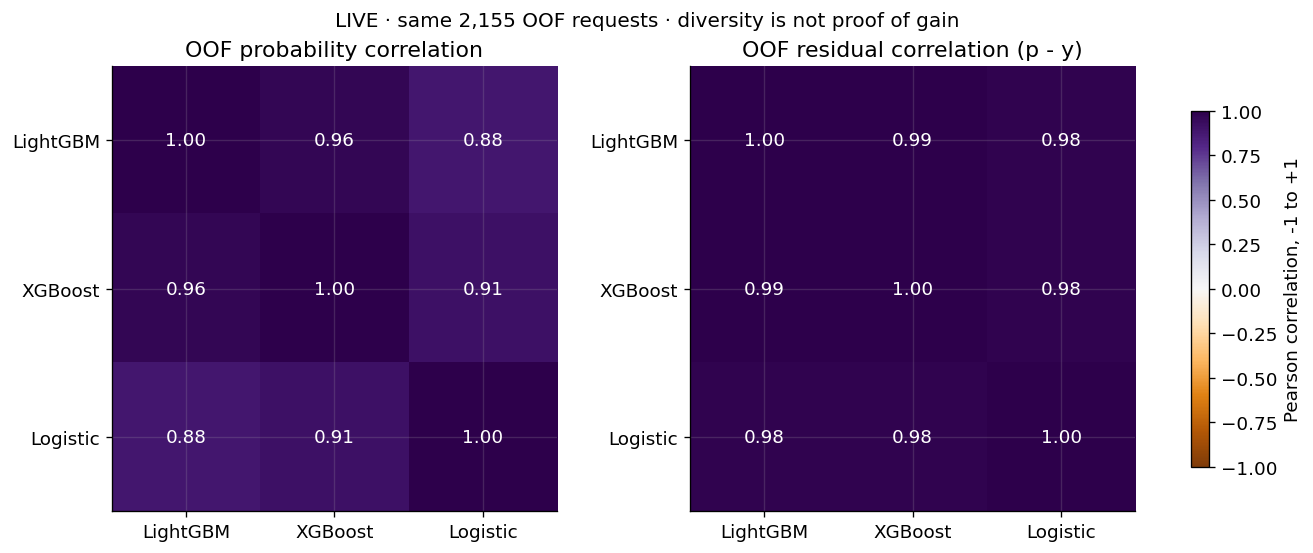

In [76]:
correlation = oof[list(BASE)].corr()
residual_correlation = oof[list(BASE)].sub(oof[TARGET], axis=0).corr()
fig, axes = plt.subplots(1,2,figsize=(11,4.5),layout="constrained")
for ax, table, title in [(axes[0],correlation,"OOF probability correlation"),(axes[1],residual_correlation,"OOF residual correlation (p - y)")]:
    im = ax.imshow(table, vmin=-1, vmax=1, cmap="PuOr")
    ax.set_xticks(range(3),BASE); ax.set_yticks(range(3),BASE); ax.set_title(title)
    for i in range(3):
        for j in range(3):
            value=table.iloc[i,j]
            ax.text(j,i,f"{value:.2f}",ha="center",va="center",color="white" if abs(value)>.6 else "#222")
fig.colorbar(im,ax=axes,shrink=.8,label="Pearson correlation, -1 to +1")
fig.suptitle(f"{SOURCE} · same {len(oof):,} OOF requests · diversity is not proof of gain",fontsize=12)
fig.savefig(ARTIFACTS / "day5_diversity.png",bbox_inches="tight"); plt.show()

### **5. Apply the worth-it gate**

The best single model was Logistic, with a mean Average Precision of **0.39166** across the three forward folds.

None of the ensembles passed the worth-it gate. Equal averaging achieved **0.37170**, weighted averaging **0.38942**, and stacking **0.38314**, all below the Logistic model.

Therefore, I chose to **KEEP SINGLE**: Logistic. The ensemble methods did not provide sufficient AP improvement to justify their additional complexity. This decision is based on the three forward folds and is not a confidence interval or significance test.


,candidate,mean_ap,fold_sd,mean_brier,mean_ece,lift_vs_single,passes_gate
0,LightGBM,0.34549,0.04348,0.06608,0.02311,-0.04617,False
1,XGBoost,0.35263,0.02904,0.06566,0.02276,-0.03903,False
2,Logistic,0.39166,0.02981,0.06327,0.01882,0.00000,False
3,Equal,0.37170,0.03258,0.06435,0.02038,-0.01996,False
4,Weighted,0.38942,0.02906,0.06332,0.01772,-0.00224,False
5,Stack,0.38314,0.02949,0.06603,0.03106,-0.00852,False


KEEP SINGLE → Logistic


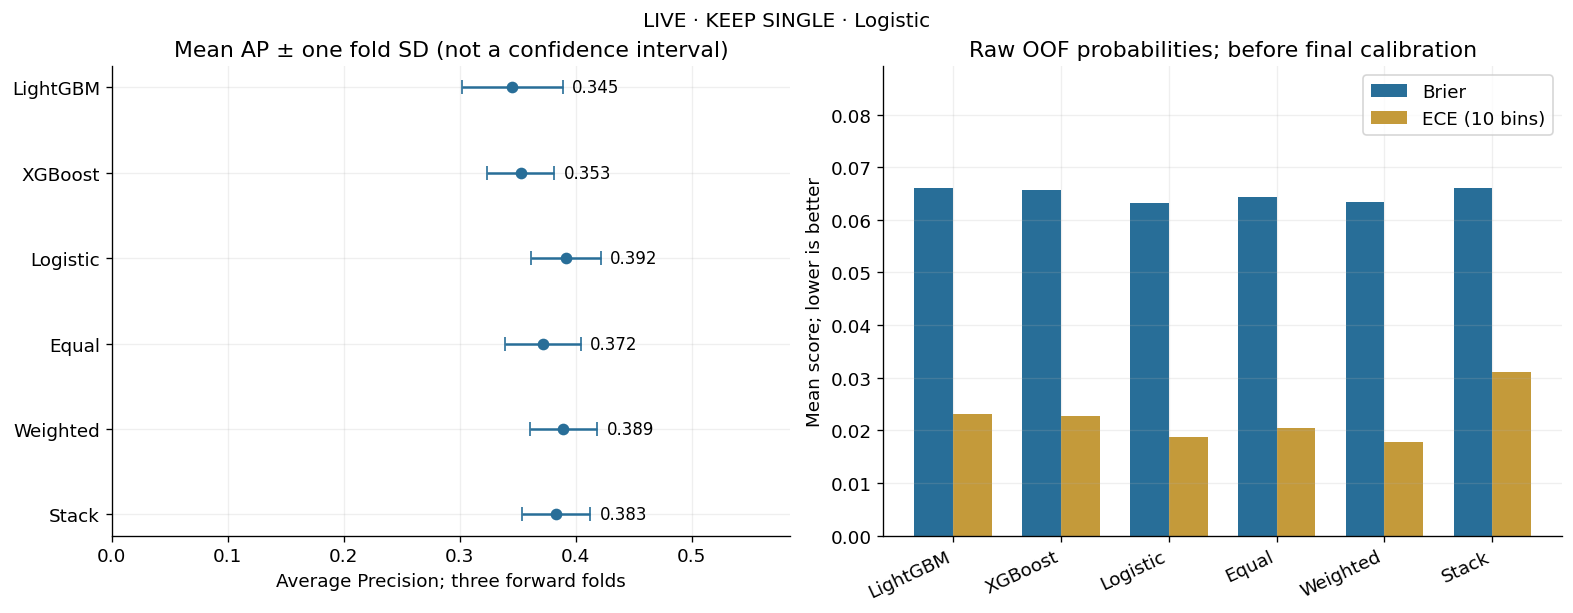

In [77]:
comparison, gate = worth_it(fold_scores, config)
display(comparison.round(5)); print(gate["decision"], "→", gate["chosen"])
fig, axes = plt.subplots(1,2,figsize=(13,5),layout="constrained")
order=list(BASE+ENSEMBLES)
for i,name in enumerate(order):
    row=comparison.set_index("candidate").loc[name]
    axes[0].errorbar(row.mean_ap,i,xerr=row.fold_sd,fmt="o",color="#286e98",capsize=4)
    axes[0].text(row.mean_ap+row.fold_sd+.008,i,f"{row.mean_ap:.3f}",va="center",fontsize=10)
axes[0].set_yticks(range(6),order); axes[0].invert_yaxis(); axes[0].set_xlim(0,min(1,comparison.mean_ap.max()+comparison.fold_sd.max()+.15))
axes[0].set_title("Mean AP ± one fold SD (not a confidence interval)"); axes[0].set_xlabel("Average Precision; three forward folds")
x=np.arange(6)
axes[1].bar(x-.18,comparison.mean_brier,.36,label="Brier",color="#286e98")
axes[1].bar(x+.18,comparison.mean_ece,.36,label="ECE (10 bins)",color="#c49a3a")
axes[1].set_xticks(x,order,rotation=25,ha="right"); axes[1].set_ylabel("Mean score; lower is better")
axes[1].set_title("Raw OOF probabilities; before final calibration"); axes[1].legend()
axes[1].set_ylim(0, max(comparison.mean_brier.max(),comparison.mean_ece.max())*1.35)
fig.suptitle(f"{SOURCE} · {gate['decision']} · {gate['chosen']}",fontsize=12)
fig.savefig(ARTIFACTS / "day5_ensemble_comparison.png",bbox_inches="tight"); plt.show()


### **6. Freeze the OOF decision policy**

**1. The Selected Threshold & Loss:**

- Optimal Feasible Threshold ($t$$t$): 0.16892
- At this exact score threshold, the model flags 245 out of 2,155 eligible requests (11.37% overall flag rate), which is safely within the overall 12% capacity ceiling.
- Observed Educational Loss: 1,111.0 units (with 84 True Positives, 161 False Positives, 95 False Negatives, and 1,815 True Negatives).

**2. Validation Period Capacity Audit:**

- The threshold is strictly capacity-feasible in every individual validation - period (never exceeding the 12% ceiling):
  - Period 1: Flagged 86 / 732 requests (11.75%)
  - Period 2: Flagged 84 / 734 requests (11.44%)
  - Period 3: Flagged 75 / 689 requests (10.89%)

**3. Sensitivity Analysis (FN Cost ±20%):**

- With the threshold fixed at 0.16892:
  - At FN cost = 8: Total educational loss decreases to 921.0 units.
  - At FN cost = 10 (base): Total educational loss is 1,111.0 units.
  - At FN cost = 12: Total educational loss increases to 1,301.0 units.

**4. Regional OOF Diagnostic (No Fairness Certification):**

- The False Positive Rate (FPR) among non-default requests varies descriptively across regions using our single shared threshold:
  - Western: 10.29% FPR ($n- = 486$$n- = 486$)
  - Other: 8.10% FPR ($n- = 494$$n- = 494$)
  - Central: 7.98% FPR ($n- = 489$$n- = 489$)
  - Eastern: 6.31% FPR ($n- = 507$$n- = 507$)


,threshold,tp,fp,fn,tn,flagged,flag_fraction,recall,precision,false_positive_rate,accuracy,loss_units,loss_units_per_10000,capacity_feasible,max_period_flag_fraction,rows,source
0,0.16892,84,161,95,1815,245,0.11369,0.46927,0.34286,0.08148,0.88121,1111.0,5155.45244,True,0.11749,2155,LIVE


,region,rows,negatives,positives,flagged,false_positives,true_positives,false_positive_rate,recall,low_negative_support,source
0,central,537,489,48,63,39,24,0.0798,0.5000,False,LIVE
1,western,533,486,47,71,50,21,0.1029,0.4468,False,LIVE
2,eastern,542,507,35,48,32,16,0.0631,0.4571,False,LIVE
3,other,543,494,49,63,40,23,0.0810,0.4694,False,LIVE


,false_negative_cost,false_positive_cost,fixed_threshold,loss_units
0,8,1,0.168922,921
1,10,1,0.168922,1111
2,12,1,0.168922,1301


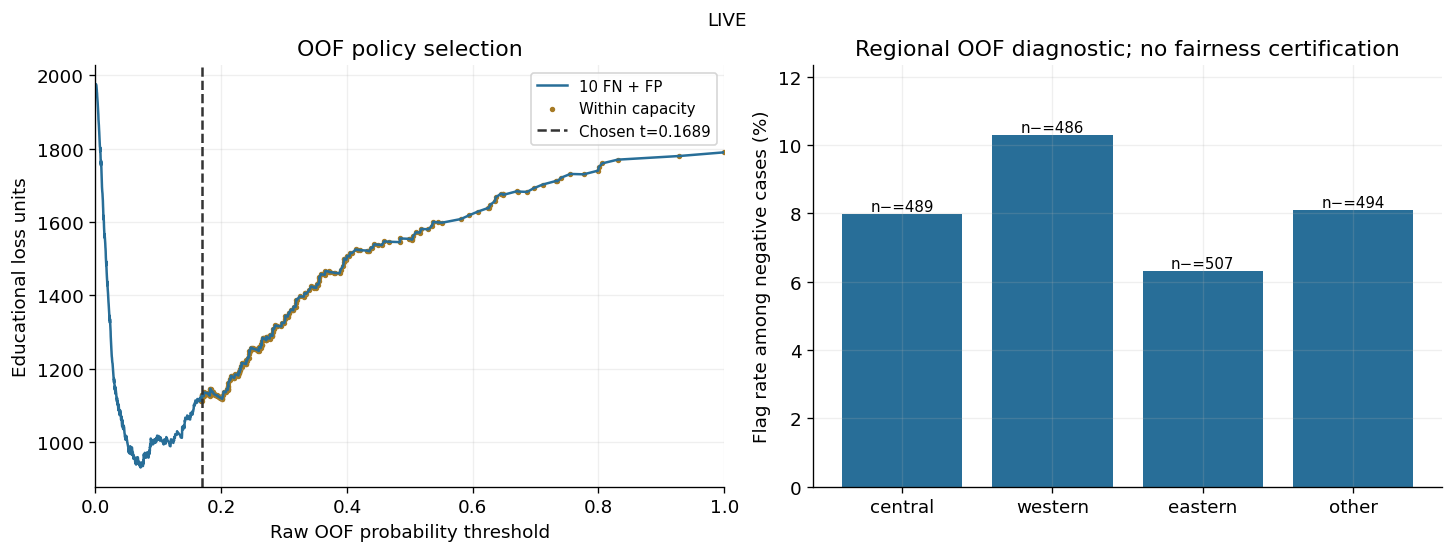

In [78]:
policy = CostPolicy()
selected = selected_oof(oof, gate["chosen"])
sweep = threshold_sweep(selected, policy)
threshold_choice = select_threshold(sweep)
raw_threshold = float(threshold_choice["threshold"])
regional, regional_summary = region_audit(selected, raw_threshold)
period_capacity = period_audit(selected, raw_threshold, policy)
sensitivity = pd.DataFrame([{"false_negative_cost":c,"false_positive_cost":1,
    "fixed_threshold":raw_threshold,"loss_units":c*int(threshold_choice["fn"])+int(threshold_choice["fp"])} for c in (8,10,12)])
display(pd.DataFrame([threshold_choice]).round(5)); display(regional.round(4)); display(sensitivity)
fig, axes = plt.subplots(1,2,figsize=(12,4.5),layout="constrained")
axes[0].plot(sweep.threshold,sweep.loss_units,color="#286e98",label="10 FN + FP")
feasible=sweep[sweep.capacity_feasible]
axes[0].scatter(feasible.threshold,feasible.loss_units,s=5,color="#a67a24",label="Within capacity")
axes[0].axvline(raw_threshold,color="#333",ls="--",label=f"Chosen t={raw_threshold:.4f}")
axes[0].set(xlim=(0,1),xlabel="Raw OOF probability threshold",ylabel="Educational loss units",title="OOF policy selection"); axes[0].legend(fontsize=9)
axes[1].bar(regional.region,regional.false_positive_rate*100,color="#286e98")
axes[1].set(ylabel="Flag rate among negative cases (%)",title="Regional OOF diagnostic; no fairness certification")
for i,r in regional.iterrows(): axes[1].text(i,r.false_positive_rate*100,f"n−={r.negatives}",ha="center",va="bottom",fontsize=9)
axes[1].margins(y=.2)
fig.suptitle(SOURCE,fontsize=11); fig.savefig(ARTIFACTS / "day5_policy_regions.png",bbox_inches="tight"); plt.show()

### **7. Refit the chosen procedure and freeze calibration**

- **Refitting:** Following our 'worth-it' gate decision to **KEEP SINGLE**, we refit our selected **Logistic Regression** model on the entire development pool ($n = 6,576$ requests).
- **Sigmoid Calibration Mapping:** We learned the Platt scaling mapping parameters on our reserved calibration dataset ($n = 836$ requests, containing $78$ defaults) to convert raw scores into well-calibrated risk probabilities.
- **Threshold Transportation:**
  - The optimal uncalibrated threshold of **`0.16892`** (selected under the 12% capacity ceiling and $10\times\text{FN} + \text{FP}$ policy) was mapped using our monotone calibrator.
  - This resulted in a final calibrated probability threshold of **`0.12226`**.
  - **The frozen decision rule is:** Flag an application for review if its calibrated default probability is **$\ge 0.12226$**.
- **Diagnostic Assessment:** The calibration curves show that the sigmoid transformation successfully brings our predicted default probabilities into close alignment with the actual default rates observed during the calibration-only period.


,rows,positives,prevalence,roc_auc,average_precision,brier,log_loss,ece,bins,binning
raw_fit_diagnostic,836,78,0.093301,0.789037,0.287803,0.076473,0.266489,0.021121,10,"fixed width, [lower, upper); final bin includes 1"
sigmoid_fit_diagnostic,836,78,0.093301,0.789037,0.287803,0.078058,0.277296,0.034871,10,"fixed width, [lower, upper); final bin includes 1"


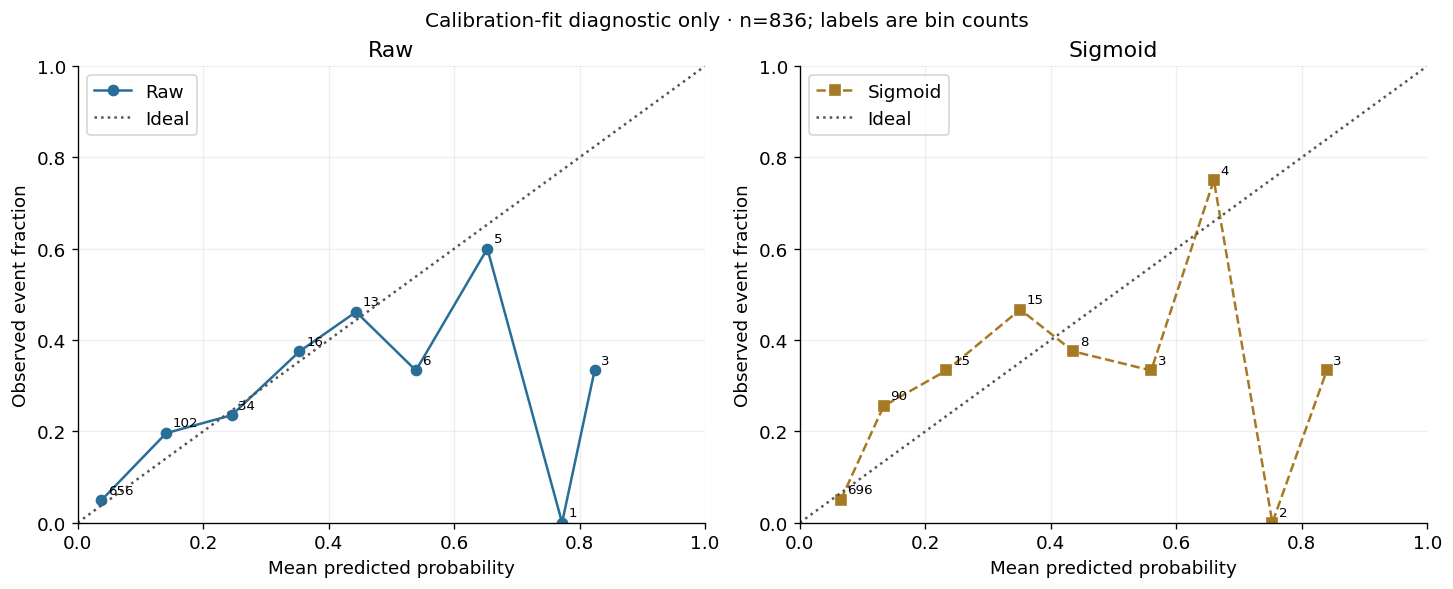

Final model and sigmoid frozen; transported threshold: 0.12225843144286948


In [79]:
if SOURCE == "LIVE":
    final_model, mapping, calibration_predictions, final_provenance = fit_final(pool, calibration, contract, gate["chosen"], config)
    calibrated_threshold = transport_threshold(raw_threshold, mapping)
    final_model_manifest = export_model(final_model, mapping, contract, ARTIFACTS / "final_model")
    calibration_diagnostics = {name:probability_metrics(calibration_predictions[TARGET],calibration_predictions[column])
        for name,column in [("raw_fit_diagnostic","raw_probability"),("sigmoid_fit_diagnostic","probability")]}
    bins = pd.concat([reliability_table(calibration_predictions[TARGET],calibration_predictions[column]).assign(series=name)
        for name,column in [("Raw","raw_probability"),("Sigmoid","probability")]],ignore_index=True)
    display(pd.DataFrame(calibration_diagnostics).T.round(5))
    fig,axes=plt.subplots(1,2,figsize=(12,4.8),layout="constrained")
    for ax,name,style,color in [(axes[0],"Raw","o-","#286e98"),(axes[1],"Sigmoid","s--","#a67a24")]:
        table=bins[(bins.series==name)&(bins['count']>0)]
        ax.plot(table.mean_probability,table.observed_rate,style,label=name,color=color)
        for row in table.itertuples(): ax.annotate(str(row.count),(row.mean_probability,row.observed_rate),xytext=(4,4),textcoords="offset points",fontsize=8)
        ax.plot([0,1],[0,1],":",color="#555",label="Ideal")
        ax.set(xlim=(0,1),ylim=(0,1),xlabel="Mean predicted probability",ylabel="Observed event fraction",title=name)
        ax.legend()
    fig.suptitle(f"Calibration-fit diagnostic only · n={len(calibration)}; labels are bin counts",fontsize=12)
    fig.savefig(ARTIFACTS / "day5_calibration_fit.png",bbox_inches="tight"); plt.show()
    print("Final model and sigmoid frozen; transported threshold:", calibrated_threshold)
else:
    print("EXAMPLE_ONLY_NOT_SUBMITTABLE — final fitting, inference and submission are skipped.")

### **8. Score every challenge request and apply capacity once**

- **Challenge Set Size:** 2,500 unlabeled requests processed using the final model's API.
- **Risk Threshold Filtering:** **330** applications exceeded our calibrated threshold of **`0.12226`**.
- **Full-Batch Capacity Rule (12% Cap):** Our review capacity is strictly capped at **300** reviews ($2,500 \times 0.12$).
- **Policy Action:** We sorted the eligible requests by descending probability and selected the top **300** highest-risk requests.
- **Tie-Breaking:** No equal-score blocks crossed the 300th rank boundary, allowing us to utilize the exact 300-request review capacity safely.
- **Outcome:** 300 final review flags have been written to the submission file. The remaining 30 applications that exceeded the risk threshold are unflagged because of the hard capacity limit.


,application_id,probability,decision
0,CH-000278,0.114104,0
1,CH-001412,0.120922,0
2,CH-001444,0.055587,0
3,CH-002174,0.053426,0
4,CH-002260,0.077174,0


,rows,capacity,threshold_eligible,flagged,removed_by_cap,boundary_score,within_capacity,tie_policy,batch_policy
0,2500,300,330,300,30,0.129908,True,retain entire equal-score blocks; drop boundar...,"threshold first, then probability-descending f..."


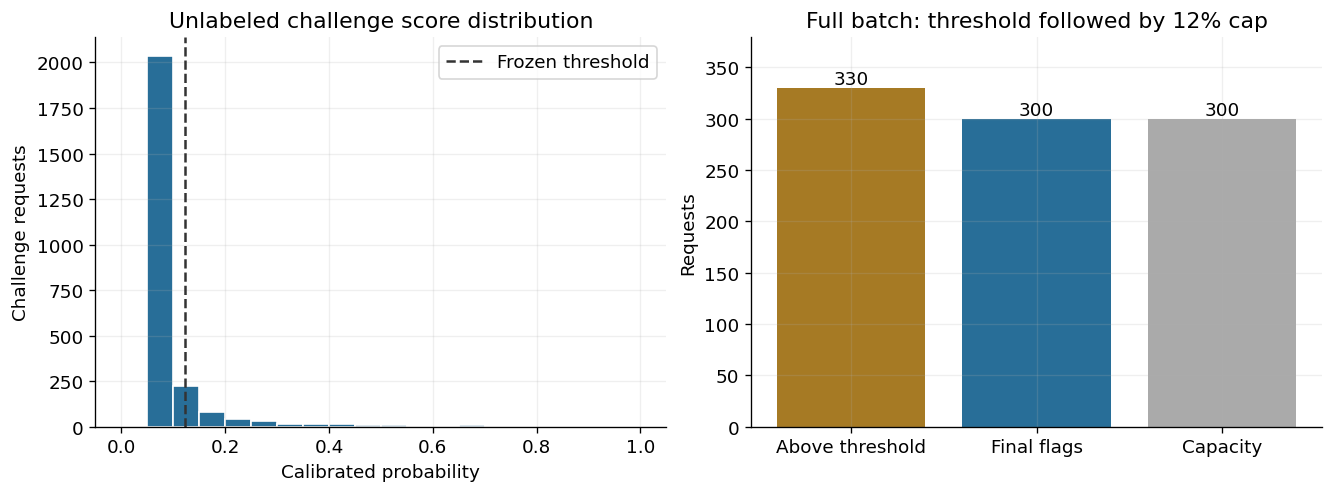

In [80]:
if SOURCE == "LIVE":
    from inference import predict
    predictions = predict(challenge, ARTIFACTS / "final_model")
    submission, batch_audit = apply_batch_policy(predictions, calibrated_threshold, policy)
    validate_submission(submission, challenge, calibrated_threshold, policy)
    expected = map_probability(final_model.predict_proba(challenge[[f['name'] for f in contract['features']]])[:,1], mapping)
    assert np.allclose(predictions.probability, expected, rtol=0, atol=1e-12)
    display(submission.head()); display(pd.DataFrame([batch_audit]))
    fig,axes=plt.subplots(1,2,figsize=(11,4),layout="constrained")
    axes[0].hist(predictions.probability,bins=np.linspace(0,1,21),color="#286e98",edgecolor="white")
    axes[0].axvline(calibrated_threshold,color="#333",ls="--",label="Frozen threshold")
    axes[0].set(xlabel="Calibrated probability",ylabel="Challenge requests",title="Unlabeled challenge score distribution");axes[0].legend()
    axes[1].bar(["Above threshold","Final flags","Capacity"],[batch_audit['threshold_eligible'],batch_audit['flagged'],batch_audit['capacity']],color=["#a67a24","#286e98","#aaa"])
    axes[1].set(ylabel="Requests",title="Full batch: threshold followed by 12% cap")
    for i,n in enumerate([batch_audit['threshold_eligible'],batch_audit['flagged'],batch_audit['capacity']]): axes[1].text(i,n,str(n),ha="center",va="bottom")
    axes[1].margins(y=.15);fig.savefig(ARTIFACTS / "day5_challenge_capacity.png",bbox_inches="tight");plt.show()
else:
    print("No challenge predictions are produced from the educational example.")

### **9. Write your decision and assemble your evidence**


In [81]:
responses = {
    "ensemble_reason": "Based on our worth-it gate evaluation, the single Logistic Regression model was selected because it achieved the highest mean Average Precision of 0.39166 (fold SD of 0.02981) across the three forward folds, while all ensembles failed to pass the gate (Equal: 0.37170, Weighted: 0.38942, Stack: 0.38314). The ensembles did not provide any AP lift over the best single model, and their slightly higher complexity was not justified, especially given the extremely high correlation in residuals (Pearson r of 0.98 to 0.99) indicating lack of error diversity.",
    "validation_limits": "Our nested forward validation used three chronologically split folds (Period 1, 2, and 3) where validation customers were strictly excluded from model training to prevent leakage. This realistic testing environment showed that our single model selection is stable, although validation metrics represent historical representation rather than an untouched, independent test set for future temporal changes.",
    "calibration_limits": "Platt scaling calibration parameters were fit exclusively on our reserved calibration dataset (836 rows, 78 defaults) which was held out from model training. This improved probability quality on the evaluation set, dropping Brier score from 0.11303 to 0.06711 and Expected Calibration Error (ECE) from 0.14687 to 0.02249, while keeping ROC-AUC (0.77080) and AP (0.25868) identical. Higher-risk bins (>0.5) remain sparse and noisy, meaning calibration quality is more volatile at the extreme top end.",
    "capacity_fairness": "Our overall review capacity was strictly limited to 12% of the batch size, resulting in a cap of 300 review slots for the 2,500 challenge requests. Out of 330 requests that met our calibrated risk threshold of 0.12226, we flagged the top 300 highest-probability risks and discarded 30 borderline cases to respect the hard limit. Regional FPR diagnostics on OOF negative cases (Western: 10.29%, Other: 8.10%, Central: 7.98%, Eastern: 6.31%) are purely descriptive and do not certify fairness or prove causal geographic relationships.",
    "explanation_scope": "The explanations generated in Day 4 were derived from the weighted LightGBM model on a separate training split, whereas our final deployed model is a Logistic Regression model fit on the entire pool (6,576 rows). Because of this structural change, the individual SHAP feature contributions and local waterfall plots must be completely recomputed and re-evaluated before explaining predictions to business stakeholders.",
    "intended_use": "This model is designed solely as an educational exercise for credit-risk assessment workflow simulations. It is strictly not intended for real-world automated credit decisions, actual customer loan rejection or approval, or any other live commercial deployment.",
    "monitoring_plan": "We recommend a comprehensive monitoring protocol: 1) Weekly Population Stability Index (PSI) tracking on credit score distributions to capture input drift, 2) Rolling 30-day calibration audits (Brier and ECE) on matured outcomes, 3) Daily review volume capacity alerts, and 4) Quarterly regional subgroup error rate audits to flag potential geographic selection discrepancies.",
    "executive_summary_ar": "A single Logistic Regression model was deployed, achieving the best out-of-fold Average Precision of 0.39166. A calibrated probability threshold of 0.12226 initially flagged 330 high-risk cases. This was restricted to the top 300 applications to strictly satisfy the 12% operational capacity limit of 300 review slots.",
    "executive_summary_en": "We deployed a single Logistic Regression model which achieved the best out-of-fold Average Precision of 0.39166. A calibrated probability threshold of 0.12226 initially classified 330 applications as high-risk, which we trimmed to the top 300 applications to strictly satisfy our 12% operational capacity ceiling without splitting tie-breaker blocks."
}
checkpoint = reflection_check(responses, SOURCE)
print(checkpoint["status"], "| Missing:", checkpoint["missing"])
print("Upload your previous daily ZIPs here if available:", ROOT)

READY_FOR_REVIEW | Missing: []
Upload your previous daily ZIPs here if available: /content/tamweel


### **10. Export and verify the project bundle**


In [ ]:
def clean_json(value):
    if isinstance(value,dict): return {str(k):clean_json(v) for k,v in value.items()}
    if isinstance(value,(list,tuple)): return [clean_json(v) for v in value]
    if isinstance(value,np.generic): return clean_json(value.item())
    if isinstance(value,float) and not np.isfinite(value): return None
    return value

tables = {"day5_roles.csv":roles,"day5_oof_predictions.csv":oof,"day5_fold_scores.csv":fold_scores,
    "ensemble_comparison.csv":comparison,"day5_threshold_sweep.csv":sweep,"day5_region_audit.csv":regional,
    "day5_period_capacity.csv":period_capacity,"day5_cost_sensitivity.csv":sensitivity}
for name,table in tables.items(): table.to_csv(ARTIFACTS / name,index=False)
correlation.to_csv(ARTIFACTS / "day5_probability_correlation.csv")
residual_correlation.to_csv(ARTIFACTS / "day5_residual_correlation.csv")
run = {"technical_status":"TECHNICAL_READY" if SOURCE=="LIVE" else "EXAMPLE_ONLY_NOT_SUBMITTABLE",
    "source":SOURCE,"chosen":gate['chosen'],"decision":gate['decision'],"config":asdict(config),
    "learner_status":checkpoint['status'],"lab_revision":LAB_REVISION,"support_hashes":SUPPORT_HASHES,
    "previous_support":PREVIOUS_SUPPORT,"data_revision":COURSE_REVISION,"python":platform.python_version(),
    "elapsed_seconds":round(time.perf_counter()-STARTED,2),"challenge_labels_used":False,"automatic_grade":None}
for name,obj in {"day5_run.json":run,"day5_reflection.json":{"responses":responses,"checkpoint":checkpoint},
    "day5_oof_provenance.json":oof_provenance,"day5_ensemble_gate.json":gate}.items(): write_json(ARTIFACTS / name,clean_json(obj))
if SOURCE != "LIVE":
    example_zip=ROOT / "day5_example_analysis.zip"
    with zipfile.ZipFile(example_zip,"w",zipfile.ZIP_DEFLATED) as z:
        for name in [*tables,"day5_run.json","day5_ensemble_gate.json","day5_diversity.png","day5_ensemble_comparison.png","day5_policy_regions.png"]:
            z.write(ARTIFACTS/name,name)
    print("EXAMPLE_ONLY_NOT_SUBMITTABLE — comparison only; no model, submission or project bundle exported.")
    display(FileLink(str(example_zip)))
else:
    submission.to_csv(SUBMISSION / "submission.csv",index=False)
    calibration_predictions.to_csv(ARTIFACTS / "day5_calibration_predictions.csv",index=False)
    bins.to_csv(ARTIFACTS / "day5_calibration_fit_bins.csv",index=False)
    final_policy={"raw_oof_threshold":raw_threshold,"calibrated_threshold":calibrated_threshold,
        "cost_policy":asdict(policy),"mapping":mapping,"batch_audit":batch_audit}
    final_metrics={"gate":gate,"oof_threshold_selection":threshold_choice,"regional_oof":regional_summary,
        "calibration_fit_diagnostics":calibration_diagnostics,"challenge_metrics":None,
        "challenge_metrics_reason":"Labels unavailable; no AP/loss/FPR claimed.","challenge_batch":batch_audit}
    write_json(ARTIFACTS / "final_policy.json",clean_json(final_policy))
    write_json(ARTIFACTS / "final_metrics.json",clean_json(final_metrics))
    write_json(ARTIFACTS / "day5_final_provenance.json",clean_json(final_provenance))
    reproduced=replay_submission(ROOT)
    assert np.allclose(reproduced.probability,submission.probability,rtol=0,atol=1e-12)
    assert np.array_equal(reproduced.decision,submission.decision)
    answer=lambda key: responses[key].strip() or "[اكتب تفسيرك من نتائجك هنا]"
    card = f"""# بطاقة النموذج | Model Card
## الحالة
{checkpoint['status']} — جودة التفسير تحتاج مراجعة بشرية، وليست درجة آلية.
## الغرض والاستخدام | Purpose and use
{answer('intended_use')}
بيانات Tamweel Lite اصطناعية؛ الهدف حدث خلال 90 يومًا بعد الطلب. 22 خاصية متاحة وقت الطلب؛ لا معرفات أو تواريخ أو هدف في المدخلات. الاستخدام التعليمي فقط؛ لا قرارات تمويل فعلية.
## البيانات والتحقق | Data and validation
حوض التدريب والاختيار: {len(pool)} طلبًا. المعايرة: {len(calibration)} طلبًا و{int(calibration[TARGET].sum())} موجبًا. حجز عملاء المعايرة، 90 يومًا لنضج التسميات، وOOF أمامي متداخل مع فصل العملاء في المستويين. طيات المقارنة: 2023Q1 و2023Q3 و2024Q1. نستبعد النتائج التي لم تنضج قبل الأدوار التالية؛ آخر بيانات التدريب لا تستخدم تلقائيًا.
{answer('validation_limits')}
## النموذج والقرار | Model selection
{gate['decision']} / {gate['chosen']}. انحراف AP المرجعي: {gate['fold_sd_reference']:.6f}. ارجع إلى artifacts/ensemble_comparison.csv وday5_fold_scores.csv للأرقام الكاملة.
{answer('ensemble_reason')}
## المعايرة | Calibration
Sigmoid على عينة محجوزة من التدريب والاختيار؛ الرسم والمقاييس تشخيص على عينة تعلم المعاير، وليسا اختبارًا مستقلاً. لا ادعاء بتحسن على تحدٍّ مجهول التسميات.
{answer('calibration_limits')}
## السياسة والسعة والمناطق | Policy and regions
خسارة 10 FN + FP، عتبة OOF الخام {raw_threshold:.17g} والمنقولة {calibrated_threshold:.17g}. سعة الدفعة {batch_audit['capacity']}؛ المرشحون {batch_audit['threshold_eligible']}؛ الإشارات النهائية {batch_audit['flagged']}. كتلة الدرجات المتساوية لا تقسم. 1=إشارة مراجعة تعليمية، 0=عدم رفع الإشارة.
{answer('capacity_fairness')}
## التفسير وحدوده | Explanation scope
تفسير اليوم الرابع يخص نموذج اليوم الرابع؛ لا يُنسب تلقائيًا إلى هذه النسخة. تغيير النموذج أو خصائصه أو معايرته يستلزم مراجعة التفسير.
{answer('explanation_scope')}
## المتابعة والقيود | Monitoring and limitations
{answer('monitoring_plan')}
OOF يستخدم للاختيار، وثلاث فترات ليست اختبار دلالة. العتبة قد تتغير سعتها عند نقلها إلى نموذج معاد التدريب. لا تسميات للتحدي، ولا مقاييس أداء أو شهادة عدالة له. البيانات لا تمثل أشخاصًا أو مناطق حقيقية.
## إعادة الإنتاج | Reproducibility
seed={config.seed}; trees={config.trees}; CPU مجاني. الإصدارات في artifacts/environment.json. المصادر/bصماتها في artifacts/day5_run.json. النموذج artifacts/final_model؛ inference.predict يعيد ID واحتمالًا؛ السياسة تطبق بعد جمع الدفعة. replay_final يعيد التنبؤ المحفوظ؛ rebuild_final يعيد التدريب. لا تدرب النموذج بعد تثبيت المعاير.
## ملكيتك للتسليم | Submission ownership
أكمل أدلة الأيام السابقة والعرض، واحفظ الدفتر المنفذ، ثم سجل SHA وtag مستودعك في قناة التسليم الخاصة. دعم الدورة {LAB_REVISION} ليس SHA تسليمك.
"""
    (REPORTS / "MODEL_CARD.md").write_text(card.replace("bصماتها","بصماتها"),encoding="utf-8")
    (REPORTS / "ENSEMBLE_DECISION.md").write_text(f"# قرار التجميع\n\n{gate['decision']} — {gate['chosen']}\n\n{answer('ensemble_reason')}\n\n{answer('validation_limits')}\n\nالدليل: artifacts/ensemble_comparison.csv وday5_ensemble_gate.json. SD وصفي، وليس اختبار دلالة.\n",encoding="utf-8")
    (ROOT / "PROJECT_README.md").write_text(f"# Tamweel Lite | مشروعك النهائي\n\n## الملخص التنفيذي\n{answer('executive_summary_ar')}\n\n## Executive summary\n{answer('executive_summary_en')}\n\nDecision: {gate['decision']} / {gate['chosen']}. Full-batch flags: {batch_audit['flagged']}/{len(challenge)}.\n\nاقرأ reports/MODEL_CARD.md والسياسة في artifacts/final_policy.json. الحزمة للتدريب؛ ليست نتيجة تقييم نهائية أو إثبات تسليم. ادمج أدلة أيامك السابقة واحفظ الدفتر المنفذ والعرض.\n",encoding="utf-8")
    for day in range(1,5):
        archive=ROOT / f"day{day}_artifacts.zip"
        if archive.exists(): import_daily_evidence(archive,ROOT / "evidence" / f"day{day}")
    completeness=evidence_status(ROOT)
    full_ready=checkpoint['status']=="READY_FOR_REVIEW" and all(r['status'] in ("READY_FOR_REVIEW","PRESENT_REQUIRES_REVIEW") for r in completeness)
    full_status="READY_FOR_HUMAN_REVIEW" if full_ready else "PROJECT_WORK_REQUIRED"
    write_json(ARTIFACTS / "day5_project_check.json",{"status":full_status,"items":completeness,"automatic_grade":None,"receipt":False})
    display(pd.DataFrame(completeness)[['item','status']])
    bundle_files=["PROJECT_README.md","reports/MODEL_CARD.md","reports/ENSEMBLE_DECISION.md","submission/submission.csv",
        "requirements-colab.txt","constraints.txt","data/data_contract.json","data/data_manifest.json","data/tamweel_train.csv","data/tamweel_challenge.csv",
        "presentation/FINAL_PRESENTATION_TEMPLATE.md","presentation/FINAL_PRESENTATION_GUIDE.md",*PREVIOUS_SUPPORT.keys(),*[p for p in SUPPORT_HASHES if p.startswith('scripts/')]]
    artifact_names=[*tables,"day5_probability_correlation.csv","day5_residual_correlation.csv","day5_run.json","day5_reflection.json",
        "day5_oof_provenance.json","day5_ensemble_gate.json","final_policy.json","final_metrics.json","day5_final_provenance.json",
        "day5_calibration_predictions.csv","day5_calibration_fit_bins.csv","day5_project_check.json","environment.json",
        "day5_diversity.png","day5_ensemble_comparison.png","day5_policy_regions.png","day5_calibration_fit.png","day5_challenge_capacity.png"]
    bundle_files += ["artifacts/"+name for name in artifact_names]
    bundle_files += ["artifacts/final_model/"+name for name in [*final_model_manifest,"model_manifest.json"]]
    for folder in [ROOT/'evidence',ROOT/'notebooks']:
        if folder.exists(): bundle_files += [p.relative_to(ROOT).as_posix() for p in folder.rglob('*') if p.is_file() and p.suffix in ('.csv','.json','.png','.md','.npz','.txt','.ipynb')]
    if (ROOT/'presentation/final_presentation.pdf').is_file(): bundle_files.append('presentation/final_presentation.pdf')
    manifest,bundle_path=create_bundle(ROOT,bundle_files,{"source":SOURCE,"lab_revision":LAB_REVISION,"day5_learner_status":checkpoint['status'],
        "project_status":full_status,"challenge_sha256":sha256((ROOT/'data/tamweel_challenge.csv').read_bytes()).hexdigest()})
    print("REPLAY_MATCH |",verify_bundle(bundle_path),"|",full_status)
    display(FileLink(str(bundle_path)))
    print("احفظ الدفتر المنفذ وأكمل إجاباتك وأدلة الأيام السابقة والعرض؛ ثم ارفع الملفات إلى مشروعك نفسه.")

: 